# Fraud Detection â€” Scale Pos Weight Pipeline
**Winner Metric:** PR-AUC (Average Precision)

**Imbalance:** scale_pos_weight + class_weight (NO SMOTE)

**Split:** Train < July 2025 | Test >= July 2025

**Threshold:** Optimized per model (â‰¥60 recall)

**Models:** XGBoost Â· LightGBM Â· CatBoost Â· Random Forest Â· Neural Network Â· Ensemble

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, precision_recall_curve,
    roc_curve, classification_report
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings, time
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
print("  Libraries imported")

  Libraries imported


In [3]:
# Load Data
df = pd.read_csv(r"C:\\Users\\mitul\\OneDrive\\Documents\\arya\\fraud\\CFM_anon_final.csv", low_memory=False)
print(f"Loaded {len(df):,} rows, {len(df.columns)} columns")

df["data_created_at_parsed"] = pd.to_datetime(df["data_created_at"], format="ISO8601")
print(f"Date range: {df['data_created_at_parsed'].min()} to {df['data_created_at_parsed'].max()}")
df

Loaded 474,619 rows, 104 columns
Date range: 2022-10-14 16:25:32.528734 to 2025-12-11 14:31:49.942114


,Claim_No,Claim Type,Investigation Outcome,Assign Date,Final Status,Investigated,Age_of_Patient_Years,Gender_of_Patient,Relationship_of_Patient_with_Employee,Company_Date_of_Joining,...,Investigation Outcome1,Old_Target,Claims_Stage,Miscllenious_policy_ID,Target_as_investigation,Target_as_fraud,hospital_name_anon,HID_anon,CID_anon,data_created_at_parsed
0,4704BD2D2,Reimbursement,NaN,NaN,Paid By Bank,0.0,35,FEMALE,Spouse,01/01/22,...,NaN,0,1,NaN,0,0,HOSP_1d5417823d433b32,HID_1de287a6eaa321b9,CID_35eb1dad1585e22e,2022-11-28 17:55:59.280182
1,568D006E0,NaN,NaN,NaN,NaN,NaN,30,MALE,Self,02/05/22,...,NaN,0,1,NaN,0,0,HOSP_c39bd64618fb6af3,HID_4dbb9bb61d63f1e8,CID_35eb1dad1585e22e,2022-10-15 00:00:00.000000
2,2C59C8F36,NaN,NaN,NaN,NaN,NaN,30,FEMALE,Self,02/05/22,...,NaN,0,1,NaN,0,0,HOSP_d9dbad32bb5f7a4a,HID_17353a59b0521cb5,CID_35eb1dad1585e22e,2022-10-15 00:00:00.000000
3,F92F3B35E,NaN,NaN,NaN,NaN,NaN,36,MALE,Self,30/03/21,...,NaN,0,1,NaN,0,0,HOSP_a28f20daaae55891,HID_c051b2f0105c5ee1,CID_35eb1dad1585e22e,2022-10-15 00:00:00.000000
4,4E6DD3859,NaN,NaN,NaN,NaN,NaN,30,FEMALE,Self,02/07/21,...,NaN,0,3,NaN,0,0,HOSP_599780b1a978ffd8,HID_f88cecb3346a9913,CID_55f2d0646a511aaa,2022-10-15 00:00:00.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
474614,E389ACAF3,NaN,NaN,NaN,NaN,NaN,41,FEMALE,Spouse,01/01/25,...,NaN,0,1,FGH,0,0,HOSP_851dc0d6c61038ae,HID_cae66cfa58939741,CID_35eb1dad1585e22e,2025-12-11 14:20:24.228533
474615,F1A87269D,NaN,NaN,NaN,NaN,NaN,42,FEMALE,Spouse,NaN,...,NaN,0,1,FHA,0,0,HOSP_752815a04f5047cf,HID_7abbf9b18e0f3ae2,CID_14158350ab4193f7,2025-12-11 14:23:35.099413
474616,50E6467AC,NaN,NaN,NaN,NaN,NaN,57,FEMALE,Mother,23/11/24,...,NaN,0,1,FGH,0,0,HOSP_806f694d4f7cae94,HID_b32ac9b3adc3a650,CID_35eb1dad1585e22e,2025-12-11 14:25:08.907021
474617,2FF5BEDC5,NaN,NaN,NaN,NaN,NaN,30,MALE,Self,15/12/24,...,NaN,0,1,FGH,0,0,HOSP_0eacb5a455071e6c,HID_77b52820e361f6a3,CID_35eb1dad1585e22e,2025-12-11 14:25:20.539378


# Missing Value Handling Strategy

We are **NOT dropping NaNs** â€” we handle them in a structured, leakage-safe, and model-aware manner.

---

##  Numeric Columns

- Fill missing values using the **train set median**  
  *(Never global median â€” prevents data leakage)*
- Replace `inf` / `-inf` with the **train set median**

---

##  Categorical Columns

- Fill missing values with `'Unknown'`  
  *(Treated as a valid, separate category)*
- Apply **Frequency Encoding**
- Apply **Label Encoding**

---

##  Date Columns

- Parse using:
  `errors='coerce'`  
  â†’ Invalid dates are converted to `NaT`

- For derived features (e.g., `hospitalization_days`):
  - Fill with **train set median**

- For features that cannot be computed:
  - Fill with `0`  
  **or**
  - Fill with **train set median**

---

##  Missingness as a Predictive Signal

We explicitly model missing value patterns:

- Create:
  - `num_missing_values`
  - `{field}_is_missing` indicator features

This enables the model to:
- Capture structural missingness
- Learn patterns correlated with fraud
- Improve predictive performance when missingness itself carries signal


In [4]:
# Time Split + Remove Leaky Features
train_mask = df["data_created_at_parsed"] < "2025-07-01"
test_mask  = df["data_created_at_parsed"] >= "2025-07-01"
print(f"Train: {train_mask.sum():,} | Test: {test_mask.sum():,}")

leaky = ["Investigation Outcome","Investigation Outcome1","Old_Target",
         "Final Status","Investigated","Assign Date","Claim Type","Approved_Amount_INR"]
df_clean = df.drop(columns=[c for c in leaky if c in df.columns])
print(f"Removed {len([c for c in leaky if c in df.columns])} leaky columns")

target_inv   = df_clean["Target_as_investigation"].copy()
target_fraud = df_clean["Target_as_fraud"].copy()
print(f"Target_inv   : {np.bincount(target_inv.values)}")
print(f"Target_fraud : {np.bincount(target_fraud.values)}")

drop_ids = ["Claim_No","hospital_name_anon","Hospital_HID","Policy_number",
            "Miscllenious_policy_ID","data_created_at","data_created_at_parsed",
            "Target_as_investigation","Target_as_fraud"]
feat = df_clean.drop(columns=[c for c in drop_ids if c in df_clean.columns])

train_idx = train_mask
test_idx  = test_mask
print(f"Feature matrix: {feat.shape}")

Train: 415,751 | Test: 58,868
Removed 8 leaky columns
Target_inv   : [444819  29800]
Target_fraud : [462204  12415]
Feature matrix: (474619, 88)


In [5]:
# Phase 2A: Entity Intelligence Features
# Computed from df_clean (has targets + all columns) â€” TRAIN-ONLY aggregations
# Merged into feat by shared index before engineer_features runs

print("="*60)
print("Phase 2A: Entity Intelligence Features")
print("="*60)
t = time.time()

#  Helpers
def hhi(series):
    """Herfindahl index â€” 1.0 = all same category (fraud ring signal)."""
    if len(series) == 0: return 0.0
    counts = series.value_counts(normalize=True)
    if len(counts) == 0: return 0.0
    return float((counts ** 2).sum())

def top_pct(series):
    """Fraction belonging to most common non-null value (exclusivity / flocking score)."""
    if len(series) == 0: return 0.0
    vc = series.value_counts()   # drops NaN by default
    if len(vc) == 0: return 0.0
    return float(vc.iloc[0] / len(series))

# Pre-compute hosp_days in df_clean so disease/hospital LOS features can use it
_adm = pd.to_datetime(df_clean["Actual_Date_of_Admission"], errors="coerce")
_dis = pd.to_datetime(df_clean["Actual_Date_of_Discharge"], errors="coerce")
df_clean["_hosp_days"] = (_dis - _adm).dt.days.clip(0, 90).fillna(0)

train_d = df_clean[train_mask].copy()

# â”€â”€ Group 4: Add-on cover features (RGA 2024 â€” top fraud-prone signals) â”€â”€â”€â”€â”€â”€
addon_cols = [c for c in ["TTD","PTD","PPD","Death","Accidental_Medical_Expenses",
                          
                           "Accidental_Hospitalisation","Hospital_Cash_Allowance",
                           "Broken_Bones","Road_Ambulance_Cover",
                           "Child_Education_Support"] if c in df_clean.columns]
if addon_cols:
    feat["num_addon_covers"]  = (df_clean[addon_cols].fillna(0) > 0).sum(axis=1).values
    feat["addon_total"]       = df_clean[addon_cols].fillna(0).sum(axis=1).values
    feat["addon_to_base"]     = (feat["addon_total"] / feat["Claimed_Amt"].replace(0, np.nan)
                                 ).fillna(0).clip(0, 10)
    if "TTD" in df_clean.columns:
        feat["has_TTD"]           = (df_clean["TTD"].fillna(0) > 0).astype(int).values
    if "Hospital_Cash_Allowance" in df_clean.columns:
        feat["has_hosp_cash"]     = (df_clean["Hospital_Cash_Allowance"].fillna(0) > 0).astype(int).values
    if "TTD" in df_clean.columns and "Hospital_Cash_Allowance" in df_clean.columns:
        feat["TTD_x_hosp_cash"]   = (feat.get("has_TTD", 0) * feat.get("has_hosp_cash", 0))
    if "Hospicash_Sum_insured" in df_clean.columns:
        feat["hospicash_si"]      = df_clean["Hospicash_Sum_insured"].fillna(0).values
    if "Accidental_Hospitalization_suminsured" in df_clean.columns:
        feat["accid_hosp_si"]     = df_clean["Accidental_Hospitalization_suminsured"].fillna(0).values

# â”€â”€ Groups 1+2: Hospital enriched aggregations â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
hid = "HID_anon"
if hid in feat.columns and "Disease_Category" in df_clean.columns:
    hosp_hhi_s = train_d.groupby(hid)["Disease_Category"].apply(hhi).rename("hosp_diag_hhi")
    hosp_agg2 = (train_d.groupby(hid).agg(
        hosp_fraud_rate    =("Target_as_fraud",        "mean"),
        hosp_inv_rate      =("Target_as_investigation","mean"),
        hosp_uniq_doctors  =("Treating_Dr",            "nunique"),
        hosp_uniq_diagnoses=("Disease_Category",       "nunique"),
        hosp_uniq_cities   =("Insured_City",           "nunique"),
        hosp_mean_LOS      =("_hosp_days",             "mean"),
    ).join(hosp_hhi_s)).reset_index()
    feat = feat.merge(hosp_agg2, on=hid, how="left")
    for c in ["hosp_fraud_rate","hosp_inv_rate","hosp_uniq_doctors",
              "hosp_uniq_diagnoses","hosp_uniq_cities","hosp_mean_LOS","hosp_diag_hhi"]:
        if c in feat.columns: feat[c] = feat[c].fillna(0)
    print(f"  Hospital aggs: {hosp_agg2.shape[0]:,} hospitals")

# â”€â”€ Groups 1+2: Doctor aggregations â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
dr = "Treating_Dr"
if dr in feat.columns and hid in df_clean.columns:
    doc_excl = train_d.groupby(dr)[hid].apply(top_pct).rename("doc_exclusivity")
    doc_hhi  = train_d.groupby(dr)["Disease_Category"].apply(hhi).rename("doc_diag_hhi")
    doc_agg2 = (train_d.groupby(dr).agg(
        doc_fraud_rate  =("Target_as_fraud",        "mean"),
        doc_inv_rate    =("Target_as_investigation","mean"),
        doc_claim_mean  =("Claimed_Amt",             "mean"),
        doc_hosp_count  =("HID_anon",               "nunique"),
        doc_claim_count =("Claimed_Amt",             "count"),
    ).join(doc_excl).join(doc_hhi)).reset_index()
    feat = feat.merge(doc_agg2, on=dr, how="left")
    for c in ["doc_fraud_rate","doc_inv_rate","doc_claim_mean",
              "doc_hosp_count","doc_claim_count","doc_exclusivity","doc_diag_hhi"]:
        if c in feat.columns: feat[c] = feat[c].fillna(0)
    print(f"  Doctor  aggs: {doc_agg2.shape[0]:,} doctors")

# â”€â”€ Group 1+2: Disease aggregations â€” expected LOS (OIG upcoding signal) â”€â”€â”€â”€â”€
dis = "Disease_Category"
if dis in feat.columns:
    dis_agg2 = (train_d.groupby(dis).agg(
        dis_fraud_rate   =("Target_as_fraud",  "mean"),
        dis_expected_LOS =("_hosp_days",       "median"),
        dis_LOS_std      =("_hosp_days",       "std"),
        dis_mean_bill    =("Claimed_Amt",       "mean"),
        dis_std_bill     =("Claimed_Amt",       "std"),
        dis_uniq_hosps   =("HID_anon",          "nunique"),
    )).reset_index()
    feat = feat.merge(dis_agg2, on=dis, how="left")
    for c in ["dis_fraud_rate","dis_expected_LOS","dis_LOS_std",
              "dis_mean_bill","dis_std_bill","dis_uniq_hosps"]:
        if c in feat.columns: feat[c] = feat[c].fillna(0)
    print(f"  Disease aggs: {dis_agg2.shape[0]:,} disease categories")

# â”€â”€ Group Insurance: Employer flocking (Policy_number not in feat â€” use df_clean) â”€â”€
pol = "Policy_number"
if pol in df_clean.columns and hid in df_clean.columns:
    emp_flocking = train_d.groupby(pol)[hid].apply(top_pct).rename("emp_top_hosp_pct")
    emp_agg2 = (train_d.groupby(pol).agg(
        emp_fraud_rate    =("Target_as_fraud",        "mean"),
        emp_inv_rate      =("Target_as_investigation","mean"),
        emp_claim_count   =("Claimed_Amt",             "count"),
        emp_uniq_hospitals=("HID_anon",               "nunique"),
        emp_claim_mean    =("Claimed_Amt",             "mean"),
    ).join(emp_flocking)).reset_index()
    # Join via df_clean index (feat and df_clean share the same row order)
    emp_mapped = df_clean[[pol]].join(emp_agg2.set_index(pol), on=pol).drop(columns=[pol])
    for c in emp_mapped.columns:
        feat[c] = emp_mapped[c].values
    for c in ["emp_fraud_rate","emp_inv_rate","emp_claim_count",
              "emp_uniq_hospitals","emp_claim_mean","emp_top_hosp_pct"]:
        if c in feat.columns: feat[c] = feat[c].fillna(0)
    print(f"  Employer aggs: {emp_agg2.shape[0]:,} employers")

# Cleanup temp column
df_clean.drop(columns=["_hosp_days"], inplace=True, errors="ignore")

n_new = sum(1 for c in feat.columns if any(c.startswith(p) for p in
            ["hosp_","doc_","dis_","emp_","num_addon","addon_","has_","TTD_","hospicash","accid_"]))
print(f"\nEntity intelligence features added: {n_new}")
print(f"feat shape: {feat.shape} | Time: {time.time()-t:.1f}s")

Phase 2A: Entity Intelligence Features
  Hospital aggs: 73,536 hospitals
  Doctor  aggs: 21,340 doctors
  Disease aggs: 41 disease categories
  Employer aggs: 46,962 employers

Entity intelligence features added: 34
feat shape: (474619, 122) | Time: 25.7s


In [6]:
# Phase 2A Extra: Graph + Geo + Hospital Deep Features
# ─────────────────────────────────────────────────────────────────────────────
# Missing from main entity cell. All train-only aggregations.
# Sources: cfm_shift_v3 V3 + Practitioner's Guide (Section 2 + 5).
#
# New features:
#   city_mismatch / state_mismatch  — insured location != hospital location (ring signal)
#   hosp_repeat_patient_rate        — % claims from repeat patients at same hospital
#   hosp_weekend_adm_rate           — % weekend admissions (staged admissions signal)
#   hosp_short_stay_rate            — % stays LOS <= 1 day (staged admission / day-care fraud)
#   hosp_high_claim_rate            — % claims above hospital 75th percentile (outlier concentration)
#   pincode_claim_count             — claim volume per pincode (hotspot detection)
#   pincode_hosp_diversity          — unique hospitals per pincode (funnel = suspicious)

import os as _os
t = time.time()
print("=" * 60)
print("Phase 2A Extra: Graph + Geo + Hospital Deep Features")
print("=" * 60)

_train_d = df_clean[train_mask]
_n_added = 0

# ── Geo mismatch (insured location vs hospital location) ──────────────────────
_ic = df_clean.get('Insured_City',  pd.Series('', index=df_clean.index)).str.lower().str.strip().fillna('unk')
_hc = df_clean.get('Hospital_City', pd.Series('', index=df_clean.index)).str.lower().str.strip().fillna('unk')
if 'Insured_City' in df_clean.columns and 'Hospital_City' in df_clean.columns:
    feat['city_mismatch']  = (_ic != _hc).astype(np.float64)
    _n_added += 1

_is = df_clean.get('Insured_State',  pd.Series('', index=df_clean.index)).str.lower().str.strip().fillna('unk')
_hs = df_clean.get('Hospital_State', pd.Series('', index=df_clean.index)).str.lower().str.strip().fillna('unk')
if 'Insured_State' in df_clean.columns and 'Hospital_State' in df_clean.columns:
    feat['state_mismatch'] = (_is != _hs).astype(np.float64)
    _n_added += 1

print(f"  Geo mismatch: city_mismatch={feat.get('city_mismatch', pd.Series([0])).mean():.3f}  "
      f"state_mismatch={feat.get('state_mismatch', pd.Series([0])).mean():.3f}")

# ── Hospital deep features (train-only) ──────────────────────────────────────
if 'HID_anon' in df_clean.columns:
    _adm_dt = pd.to_datetime(df_clean['Actual_Date_of_Admission'], format='%d/%m/%y', errors='coerce')
    _dis_dt = pd.to_datetime(df_clean['Actual_Date_of_Discharge'],  format='%d/%m/%y', errors='coerce')
    _los_raw = (_dis_dt - _adm_dt).dt.days.clip(0, 365)

    # Repeat patient rate: % claims at hospital from patients who appear >1 time there
    if 'CID_anon' in df_clean.columns:
        _pat_hosp = _train_d.groupby(['HID_anon', 'CID_anon']).size().reset_index(name='_ph')
        _repeat_pats = set(
            _pat_hosp[_pat_hosp['_ph'] > 1].apply(lambda r: (r['HID_anon'], r['CID_anon']), axis=1)
        )
        _is_repeat = np.array([
            1.0 if (h, c) in _repeat_pats else 0.0
            for h, c in zip(df_clean['HID_anon'], df_clean['CID_anon'])
        ])
        _rpr = (pd.DataFrame({'H': _train_d['HID_anon'].values, 'r': _is_repeat[train_mask.values]})
                .groupby('H')['r'].mean().reset_index(name='hosp_repeat_patient_rate')
                .rename(columns={'H': 'HID_anon'}))
        feat['hosp_repeat_patient_rate'] = (df_clean[['HID_anon']]
            .merge(_rpr, on='HID_anon', how='left')['hosp_repeat_patient_rate'].fillna(0).values)
        _n_added += 1

    # Weekend admission rate
    _weekend = (_adm_dt.dt.dayofweek >= 5).astype(float)
    _wkr = (pd.DataFrame({'H': _train_d['HID_anon'].values, 'w': _weekend.values[train_mask.values]})
            .groupby('H')['w'].mean().reset_index(name='hosp_weekend_adm_rate')
            .rename(columns={'H': 'HID_anon'}))
    feat['hosp_weekend_adm_rate'] = (df_clean[['HID_anon']]
        .merge(_wkr, on='HID_anon', how='left')['hosp_weekend_adm_rate'].fillna(0).values)
    _n_added += 1

    # Short stay rate (LOS <= 1 day) — staged admission signal
    _short = (_los_raw <= 1).astype(float)
    _ssr = (pd.DataFrame({'H': _train_d['HID_anon'].values, 's': _short.values[train_mask.values]})
            .groupby('H')['s'].mean().reset_index(name='hosp_short_stay_rate')
            .rename(columns={'H': 'HID_anon'}))
    feat['hosp_short_stay_rate'] = (df_clean[['HID_anon']]
        .merge(_ssr, on='HID_anon', how='left')['hosp_short_stay_rate'].fillna(0).values)
    _n_added += 1

    # High claim rate — % claims above hospital 75th percentile (outlier concentration)
    _p75 = (_train_d.groupby('HID_anon')['Claimed_Amt'].quantile(0.75)
            .reset_index(name='_p75'))
    _p75_map = df_clean[['HID_anon']].merge(_p75, on='HID_anon', how='left')['_p75'].fillna(0)
    _hcr_flag = (df_clean['Claimed_Amt'] > _p75_map).astype(float)
    _hcr = (pd.DataFrame({'H': _train_d['HID_anon'].values, 'h': _hcr_flag.values[train_mask.values]})
            .groupby('H')['h'].mean().reset_index(name='hosp_high_claim_rate')
            .rename(columns={'H': 'HID_anon'}))
    feat['hosp_high_claim_rate'] = (df_clean[['HID_anon']]
        .merge(_hcr, on='HID_anon', how='left')['hosp_high_claim_rate'].fillna(0.5).values)
    _n_added += 1

# ── Pincode clustering (hotspot detection) ────────────────────────────────────
if 'Pincode' in df_clean.columns:
    _pc_cnt = (_train_d.groupby('Pincode').size()
               .reset_index(name='pincode_claim_count'))
    feat['pincode_claim_count'] = (df_clean[['Pincode']]
        .merge(_pc_cnt, on='Pincode', how='left')['pincode_claim_count'].fillna(0).values)
    _n_added += 1

    if 'HID_anon' in df_clean.columns:
        _pc_hdiv = (_train_d.groupby('Pincode')['HID_anon'].nunique()
                    .reset_index(name='pincode_hosp_diversity'))
        feat['pincode_hosp_diversity'] = (df_clean[['Pincode']]
            .merge(_pc_hdiv, on='Pincode', how='left')['pincode_hosp_diversity'].fillna(0).values)
        _n_added += 1

print(f"Graph/geo/hospital-deep features added: {_n_added}")
print(f"feat shape: {feat.shape} | Time: {time.time()-t:.1f}s")

Phase 2A Extra: Graph + Geo + Hospital Deep Features
  Geo mismatch: city_mismatch=0.833  state_mismatch=0.496
Graph/geo/hospital-deep features added: 8
feat shape: (474619, 130) | Time: 1.7s


In [7]:
# Phase 2A Group 3: Velocity Features (time-windowed rolling claim counts)
# Per-entity claim frequency in 30d/90d windows — captures fraud spike patterns.
# Uses ALL data (not train-only): velocity is a real-time signal, no label leakage.
# NOTE: stored as float64 (not float32) so select_dtypes("int64","float64") includes them.
print("="*60)
print("Group 3: Velocity Features")
print("="*60)
t_vel = time.time()

_dates_ns = df_clean["data_created_at_parsed"].values.astype("int64")  # nanoseconds
_d30 = int(30 * 24 * 3600 * 1e9)
_d90 = int(90 * 24 * 3600 * 1e9)

def _compute_vel(entity_col, prefix):
    """
    Rolling claim count per entity in 30d and 90d left-open windows.
    Left-open: counts claims in [t-window, t) — excludes current claim, no leakage.
    Uses searchsorted on sorted dates within each entity group: O(N log N) total.
    """
    out30 = np.zeros(len(df_clean), dtype=np.float64)   # float64 so select_dtypes keeps them
    out90 = np.zeros(len(df_clean), dtype=np.float64)
    for ent, sub in df_clean.groupby(entity_col):
        if len(sub) < 2:
            continue
        idx   = sub.index.values
        d     = _dates_ns[idx]
        order = np.argsort(d)
        sd    = d[order]      # sorted dates (nanoseconds)
        si    = idx[order]    # corresponding original df_clean row indices
        for i in range(len(sd)):
            out30[si[i]] = i - np.searchsorted(sd, sd[i] - _d30, "left")
            out90[si[i]] = i - np.searchsorted(sd, sd[i] - _d90, "left")
    feat[f"{prefix}_vel_30d"]  = out30
    feat[f"{prefix}_vel_90d"]  = out90
    feat[f"{prefix}_vel_ratio"] = out30 / (out90 + 1)   # spike detector: high = sudden burst
    print(f"  {entity_col}: max_30d={out30.max():.0f} max_90d={out90.max():.0f}")

# Hospital velocity (79K unique hospitals — avg 6 claims each, fast)
if "HID_anon" in df_clean.columns and "data_created_at_parsed" in df_clean.columns:
    _compute_vel("HID_anon", "hosp")

# Employer velocity (48K unique employers)
if "Policy_number" in df_clean.columns and "data_created_at_parsed" in df_clean.columns:
    _compute_vel("Policy_number", "emp")

# CID_anon = 33 corporate clients (not individual patients) — velocity skipped

# Policy inception flags (how soon after policy start was the claim filed?)
# Risk_Inception_Date is the risk start date — different from Date_of_Joining_the_Policy
if "Risk_Inception_Date" in df_clean.columns and "Actual_Date_of_Admission" in df_clean.columns:
    _risk_inc = pd.to_datetime(df_clean["Risk_Inception_Date"], format="%d/%m/%y", errors="coerce")
    _adm_date = pd.to_datetime(df_clean["Actual_Date_of_Admission"], errors="coerce")
    _days_inc  = (_adm_date - _risk_inc).dt.days.clip(0, 3650).fillna(365)
    feat["days_from_risk_inc"] = _days_inc.values
    feat["risk_inc_flag_30d"]  = (_days_inc < 30).astype(int).values
    feat["risk_inc_flag_60d"]  = (_days_inc < 60).astype(int).values
    feat["risk_inc_flag_90d"]  = (_days_inc < 90).astype(int).values
    print(f"  Policy inception flags: <30d={feat['risk_inc_flag_30d'].sum():,} "
          f"<60d={feat['risk_inc_flag_60d'].sum():,} <90d={feat['risk_inc_flag_90d'].sum():,}")

vel_cols = [c for c in feat.columns if "_vel_" in c or "risk_inc" in c]
print(f"\nVelocity features added: {len(vel_cols)}")
print(f"feat shape: {feat.shape} | Time: {time.time()-t_vel:.1f}s")


Group 3: Velocity Features
  HID_anon: max_30d=3179 max_90d=8426
  Policy_number: max_30d=967 max_90d=2082
  Policy inception flags: <30d=46,547 <60d=74,070 <90d=103,561

Velocity features added: 10
feat shape: (474619, 140) | Time: 4.7s


In [ ]:
# Phase 2C: OOF Target Encoding
# ─────────────────────────────────────────────────────────────────────────────
# Plain Phase 2A aggregation uses ALL train labels to compute e.g. hosp_fraud_rate.
# When that rate is used as a feature during model training, the current claim's own
# label is baked into it → mild leakage that inflates apparent train performance.
#
# OOF (Out-Of-Fold) encoding fixes this:
#   Train set: 5 time-contiguous folds. For fold i, rates are computed on folds 1..i-1,i+1..5
#              so the current claim's label is NEVER used to compute its own feature.
#   Test set:  full train-set aggregation (same data as Phase 2A, just a separate column).
#
# Additive smoothing: rate = (sum_fraud + k * global_mean) / (count + k)
#   prevents rare entities (1-2 claims) from having extreme rates.
#
# Entities encoded:
#   HID_anon        (79K hospitals)   → oof_hosp_fraud / oof_hosp_inv
#   Treating_Dr     (21K doctors)     → oof_doc_fraud  / oof_doc_inv
#   Disease_Category (81 diseases)    → oof_dis_fraud  / oof_dis_inv
#   Policy_number   (48K employers)   → oof_emp_fraud  / oof_emp_inv
#
# Adds 8 new features to feat.
import time as _time
_t0 = _time.time()
print("Phase 2C: OOF Target Encoding...")

N_FOLDS = 5
SMOOTH  = 10    # additive smoothing weight — equivalent to adding 10 "average" claims

ENTITIES = [
    ("HID_anon",         "oof_hosp"),
    ("Treating_Dr",      "oof_doc"),
    ("Disease_Category", "oof_dis"),
    ("Policy_number",    "oof_emp"),   # still in df_clean even though dropped from feat
]
TARGET_PAIRS = [
    ("Target_as_fraud",         "fraud"),
    ("Target_as_investigation", "inv"),
]

# Global train means (used as smoothing prior + fallback for unseen entities)
_tr = train_mask.values
glob_mean = {t: df_clean.loc[train_mask, t].mean() for t, _ in TARGET_PAIRS}

# Initialise new columns in feat with global mean (safe default)
for _, pfx in ENTITIES:
    for _, sfx in TARGET_PAIRS:
        feat[f"{pfx}_{sfx}"] = np.nan

# ── Build 5 time-sorted folds over train set ────────────────────────────────
_tr_pos   = np.where(_tr)[0]                                        # positional row indices
_tr_dates = df_clean["data_created_at_parsed"].values[_tr_pos]      # timestamps
_sort     = np.argsort(_tr_dates)
_sorted   = _tr_pos[_sort]                                          # train rows, sorted by date
_fsz      = len(_sorted) // N_FOLDS
_folds    = [_sorted[i*_fsz : (i+1)*_fsz if i < N_FOLDS-1 else None]
             for i in range(N_FOLDS)]

# ── OOF encoding over train folds ───────────────────────────────────────────
for fi, val_pos in enumerate(_folds):
    fit_pos = np.concatenate([_folds[j] for j in range(N_FOLDS) if j != fi])
    fit_df  = df_clean.iloc[fit_pos]
    val_df  = df_clean.iloc[val_pos]

    for col, pfx in ENTITIES:
        for target, sfx in TARGET_PAIRS:
            gm  = glob_mean[target]
            agg = fit_df.groupby(col)[target].agg(["sum","count"])
            agg["rate"] = (agg["sum"] + SMOOTH * gm) / (agg["count"] + SMOOTH)
            mapped = val_df[col].map(agg["rate"]).fillna(gm).values
            # val_pos are positional indices; feat has RangeIndex → same as labels
            feat.iloc[val_pos, feat.columns.get_loc(f"{pfx}_{sfx}")] = mapped

# ── Test set: aggregate on full training data ────────────────────────────────
_test_pos = np.where(~_tr)[0]
for col, pfx in ENTITIES:
    for target, sfx in TARGET_PAIRS:
        gm  = glob_mean[target]
        
        agg = df_clean.loc[train_mask].groupby(col)[target].agg(["sum","count"])
        agg["rate"] = (agg["sum"] + SMOOTH * gm) / (agg["count"] + SMOOTH)
        mapped = df_clean.loc[test_mask, col].map(agg["rate"]).fillna(gm).values
        feat.iloc[_test_pos, feat.columns.get_loc(f"{pfx}_{sfx}")] = mapped

oof_cols = [f"{pfx}_{sfx}" for _, pfx in ENTITIES for _, sfx in TARGET_PAIRS]
print(f"  Added {len(oof_cols)} OOF columns: {oof_cols}")

# Sanity checks
_train_nan  = feat.loc[train_mask, oof_cols].isna().sum().sum()
_test_nan   = feat.loc[test_mask,  oof_cols].isna().sum().sum()
print(f"  NaN check  — train: {_train_nan}  test: {_test_nan}")

# Quick peek: OOF hospital fraud rate should be correlated with plain hosp_fraud_rate
if "hosp_fraud_rate" in feat.columns:
    _corr = feat.loc[train_mask, ["hosp_fraud_rate","oof_hosp_fraud"]].corr().iloc[0,1]
    print(f"  Correlation(hosp_fraud_rate, oof_hosp_fraud) [train] = {_corr:.4f}  (expect > 0.90)")

print(f"  Done in {_time.time()-_t0:.1f}s  |  feat shape: {feat.shape}")


Phase 2C: OOF Target Encoding...
  Added 8 OOF columns: ['oof_hosp_fraud', 'oof_hosp_inv', 'oof_doc_fraud', 'oof_doc_inv', 'oof_dis_fraud', 'oof_dis_inv', 'oof_emp_fraud', 'oof_emp_inv']
  NaN check  — train: 0  test: 0
  Correlation(hosp_fraud_rate, oof_hosp_fraud) [train] = 0.4351  (expect > 0.90)
  Done in 3.5s  |  feat shape: (474619, 148)


In [9]:
# Auxiliary Target OOF Meta-Features  (cfm_shift_v3 V1 Pipeline)
# ─────────────────────────────────────────────────────────────────────────────
# Creates 5 proxy targets from billing data — each reflects a fraud-correlated
# outcome WITHOUT using the primary investigation/fraud labels.
# Sub-models (LightGBM) are trained OOF on entity + velocity + claim features
# to predict each proxy.  The OOF predictions become meta-features.
#
# Proxy targets:
#   oof_aux_approval_ratio  — Approved/Claimed (low = claim wasn't accepted at face value)
#   oof_aux_high_rejection  — Approved < 50% of Claimed  (binary)
#   oof_aux_claim_inflated  — Claimed > Total_Bill (billing inflation, no post-adj data)
#   oof_aux_si_exhaustion   — Claimed > Sum_Insured (coverage abuse, no post-adj data)
#   oof_aux_claim_to_si     — Claimed / Sum_Insured continuous ratio
#
# NOTE: approval_ratio + high_rejection use Approved_Amount_INR which is
# post-adjudication.  They are valid as TRAINING TARGETS (sub-model learns from
# claim features → predicted approval) but NOT input features.  The OOF
# prediction = "expected approval given claim characteristics" which is clean.
from lightgbm import LGBMRegressor as _LGBMReg

print("=" * 60)
print("Auxiliary Target OOF Meta-Features")
print("=" * 60)
t = time.time()

# ── Define proxy targets ──────────────────────────────────────────────────────
_AUX = {}
if 'Approved_Amount_INR' in df_clean.columns:
    _appr = (df_clean['Approved_Amount_INR'] / (df_clean['Claimed_Amt'] + 1)).clip(0, 2)
    _AUX['oof_aux_approval_ratio'] = (_appr,                              'regression')
    _AUX['oof_aux_high_rejection'] = ((_appr < 0.5).astype(float),       'binary')

if 'Claimed_Amt' in df_clean.columns and 'Total_Bill' in df_clean.columns:
    _AUX['oof_aux_claim_inflated']  = (
        (df_clean['Claimed_Amt'] > df_clean['Total_Bill']).astype(float), 'binary')

if 'Claimed_Amt' in df_clean.columns and 'Sum_Insured' in df_clean.columns:
    _AUX['oof_aux_si_exhaustion']   = (
        (df_clean['Claimed_Amt'] > df_clean['Sum_Insured']).astype(float), 'binary')
    _AUX['oof_aux_claim_to_si']     = (
        (df_clean['Claimed_Amt'] / (df_clean['Sum_Insured'] + 1)).clip(0, 2), 'regression')

print(f"Proxy targets: {list(_AUX.keys())}")

# ── Sub-model feature matrix: numeric cols of feat at this point ──────────────
_aux_num_cols = feat.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"Sub-model features: {len(_aux_num_cols)}")

# Integer positions of train/test rows in feat.values (0-based, matches df_clean order)
_tr_pos = np.where(train_mask.values)[0]
_te_pos = np.where(test_mask.values)[0]

# Time-sorted positions for OOF (earlier folds = older data)
_date_arr = df_clean['data_created_at_parsed'].values
_sort_ord  = np.argsort(_date_arr[_tr_pos])
_tr_sorted = _tr_pos[_sort_ord]

_N_AUX_FOLDS = 5
_fold_sz     = len(_tr_sorted) // _N_AUX_FOLDS

_aux_lgbm = dict(n_estimators=300, learning_rate=0.05, num_leaves=63,
                 subsample=0.8, colsample_bytree=0.8, reg_lambda=2,
                 random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)

# Full feature matrix (let LightGBM handle NaN natively)
_Xfull = feat[_aux_num_cols].values.astype(np.float32)

for _name, (_y_series, _task) in _AUX.items():
    _y_arr  = _y_series.values.astype(np.float32)
    _oof    = np.zeros(len(feat), dtype=np.float32)

    for _fi in range(_N_AUX_FOLDS):
        _s = _fi * _fold_sz
        _e = len(_tr_sorted) if _fi == _N_AUX_FOLDS - 1 else (_fi + 1) * _fold_sz
        _va_idx = _tr_sorted[_s:_e]
        _tr_idx = np.concatenate([_tr_sorted[:_s], _tr_sorted[_e:]])

        _Xf_tr, _Xf_va = _Xfull[_tr_idx], _Xfull[_va_idx]
        _yf_tr          = _y_arr[_tr_idx]

        if _task == 'binary':
            _m = LGBMClassifier(**_aux_lgbm)
            _m.fit(_Xf_tr, _yf_tr)
            _oof[_va_idx] = _m.predict_proba(_Xf_va)[:, 1]
        else:
            _m = _LGBMReg(**_aux_lgbm)
            _m.fit(_Xf_tr, _yf_tr)
            _oof[_va_idx] = _m.predict(_Xf_va)

    # Test: train on full training set, predict test
    _Xf_full_tr = _Xfull[_tr_sorted]
    _yf_full_tr = _y_arr[_tr_sorted]
    if _task == 'binary':
        _mf = LGBMClassifier(**_aux_lgbm)
        _mf.fit(_Xf_full_tr, _yf_full_tr)
        _oof[_te_pos] = _mf.predict_proba(_Xfull[_te_pos])[:, 1]
    else:
        _mf = _LGBMReg(**_aux_lgbm)
        _mf.fit(_Xf_full_tr, _yf_full_tr)
        _oof[_te_pos] = _mf.predict(_Xfull[_te_pos])

    feat[_name] = _oof.astype(np.float64)
    _tr_mean = _oof[_tr_pos].mean()
    _te_mean = _oof[_te_pos].mean()
    print(f"  {_name:<30} train_mean={_tr_mean:.4f}  test_mean={_te_mean:.4f}")

print(f"\n{len(_AUX)} aux OOF features added | feat shape: {feat.shape} | {time.time()-t:.1f}s")

Auxiliary Target OOF Meta-Features
Proxy targets: ['oof_aux_claim_inflated', 'oof_aux_si_exhaustion', 'oof_aux_claim_to_si']
Sub-model features: 107
  oof_aux_claim_inflated         train_mean=0.4704  test_mean=0.4961
  oof_aux_si_exhaustion          train_mean=0.1534  test_mean=0.2214
  oof_aux_claim_to_si            train_mean=0.4320  test_mean=0.5731

3 aux OOF features added | feat shape: (474619, 151) | 54.5s


In [10]:
# GNN embeddings — NOT concatenated to feat (64 noisy dims hurt tree models).
# Strategy: late fusion — train separate LGBM on GNN embeddings, blend probabilities.
import os

GNN_PATH = r"C:\Users\mitul\OneDrive\Documents\arya\fraud\gnn_embeddings.parquet"
if os.path.exists(GNN_PATH):
    gnn = pd.read_parquet(GNN_PATH)
    gnn_emb_cols = [c for c in gnn.columns if c.startswith("gnn_emb_")]
    print(f"GNN embeddings: {len(gnn_emb_cols)} dims | {len(gnn):,} rows")
    # Split and scale by train/test mask — row-aligned with df_clean
    gnn_arr    = gnn[gnn_emb_cols].values.astype(np.float32)
    assert len(gnn_arr) == len(df_clean), f"Row mismatch: {len(gnn_arr)} vs {len(df_clean)}"
    gnn_tr_raw = gnn_arr[train_mask.values]
    gnn_te_raw = gnn_arr[test_mask.values]
    gnn_scaler = RobustScaler()
    gnn_tr_sc  = gnn_scaler.fit_transform(gnn_tr_raw)
    gnn_te_sc  = gnn_scaler.transform(gnn_te_raw)
    print(f"GNN split: train={gnn_tr_sc.shape} | test={gnn_te_sc.shape} — ready for late fusion")
else:
    gnn = gnn_tr_sc = gnn_te_sc = None
    print("GNN embeddings not found — late fusion disabled. Run gnn_features.ipynb first.")


GNN embeddings: 64 dims | 474,619 rows
GNN split: train=(415751, 64) | test=(58868, 64) — ready for late fusion


In [11]:
# Phase 4: Anomaly Scores (DAE + Isolation Forest)
# Generated by anomaly_features.ipynb — trained on TRAIN only, scored on all rows.
# dae_recon_error: log1p-transformed reconstruction MSE (raw values can be extreme
#                  due to near-zero IQR columns — log1p makes distribution usable).
# isoforest_score: negated isolation forest score (higher = more anomalous).

ANOMALY_PATH = r"C:\Users\mitul\OneDrive\Documents\arya\fraud\anomaly_scores.parquet"
if os.path.exists(ANOMALY_PATH):
    anom = pd.read_parquet(ANOMALY_PATH)
    assert len(anom) == len(feat), f"Anomaly row mismatch: {len(anom)} vs {len(feat)}"

    # log1p the DAE error to compress extreme values (IQR blowup artefact)
    feat["dae_recon_error"] = np.log1p(anom["dae_recon_error"].values.astype(np.float64))
    feat["isoforest_score"] = anom["isoforest_score"].values.astype(np.float64)

    print(f"Anomaly features added: dae_recon_error (log1p), isoforest_score")
    print(f"  dae_recon_error — train mean: {feat.loc[train_mask, 'dae_recon_error'].mean():.3f}"
          f"  test mean: {feat.loc[test_mask, 'dae_recon_error'].mean():.3f}")
    print(f"  isoforest_score — train mean: {feat.loc[train_mask, 'isoforest_score'].mean():.4f}"
          f"  test mean: {feat.loc[test_mask, 'isoforest_score'].mean():.4f}")
    print(f"  feat shape: {feat.shape}")
else:
    print(f"WARNING: {ANOMALY_PATH} not found — anomaly features skipped.")

Anomaly features added: dae_recon_error (log1p), isoforest_score
  dae_recon_error — train mean: 5.132  test mean: 4.968
  isoforest_score — train mean: 0.3777  test mean: 0.3772
  feat shape: (474619, 153)


In [12]:
# Feature Engineering (40+ fraud-specific features)
def engineer_features(df, tidx):
    df = df.copy()

    date_cols = ["Company_Date_of_Joining","Date_of_Joining_the_Policy",
                 "Risk_Inception_Date","Risk_Expiry_Date",
                 "Expected_Date_of_Admission","Expected_Date_of_Discharge",
                 "Actual_Date_of_Admission","Actual_Date_of_Discharge",
                 "Document_Received_Date","Claim_Intimation_Date",
                 "Medical_Management_Date","Last_Document_Received_Date"]
    for c in date_cols:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], format="%d/%m/%y", errors="coerce")

    adm, dis = "Actual_Date_of_Admission", "Actual_Date_of_Discharge"
    if adm in df.columns and dis in df.columns:
        df["hosp_days"] = (df[dis]-df[adm]).dt.days.clip(0,365)
        df["hosp_days"] = df["hosp_days"].fillna(df.loc[tidx,"hosp_days"].median())

    cld = "Claim_Intimation_Date"
    if cld in df.columns and adm in df.columns:
        df["claim_delay"] = (df[cld]-df[adm]).dt.days.clip(-30,365).fillna(0)

    doj = "Date_of_Joining_the_Policy"
    if doj in df.columns and adm in df.columns:
        df["policy_age_days"] = (df[adm]-df[doj]).dt.days.clip(0,365*5)
        df["policy_age_days"] = df["policy_age_days"].fillna(df.loc[tidx,"policy_age_days"].median())

    cdoj = "Company_Date_of_Joining"
    if cdoj in df.columns and adm in df.columns:
        df["emp_tenure_days"] = (df[adm]-df[cdoj]).dt.days.clip(0,365*10)
        df["emp_tenure_days"] = df["emp_tenure_days"].fillna(df.loc[tidx,"emp_tenure_days"].median())

    if adm in df.columns:
        df["adm_month"]   = df[adm].dt.month
        df["adm_dow"]     = df[adm].dt.dayofweek
        df["adm_quarter"] = df[adm].dt.quarter
        df["adm_weekend"] = (df["adm_dow"] >= 5).astype(int)

    ca, tb, si = "Claimed_Amt", "Total_Bill", "Sum_Insured"
    if ca in df.columns and tb in df.columns:
        df["claim_to_bill"]      = (df[ca]/(df[tb]+1)).clip(upper=10)
        df["perfect_bill_match"] = ((df["claim_to_bill"]>0.99)&(df["claim_to_bill"]<=1.01)).astype(int)
        df["over_billed"]        = (df["claim_to_bill"]>1.1).astype(int)
    if ca in df.columns and si in df.columns:
        df["claim_to_si"]  = (df[ca]/(df[si]+1)).clip(upper=2)
        df["high_si_use"]  = (df["claim_to_si"]>0.5).astype(int)
        df["max_si_use"]   = (df["claim_to_si"]>0.9).astype(int)

    bc = ["Actual_Room_Charges","Doctor","Anaesthetist","Ambulance","Cardiology",
          "Equipment","Miscellaneous","OT","Package_Amount","Pathalogy",
          "Medicines","Surgeon_Fees","Radiology"]
    avail = [c for c in bc if c in df.columns]
    if avail and tb in df.columns:
        df["comp_sum"]     = df[avail].sum(axis=1)
        df["unexplained"]  = df[tb] - df["comp_sum"]
        df["unexpl_ratio"] = (df["unexplained"]/(df[tb]+1)).clip(-1,1)
        df["high_unexpl"]  = (df["unexpl_ratio"]>0.2).astype(int)
        df["neg_unexpl"]   = (df["unexpl_ratio"]<-0.1).astype(int)
        df["num_bc"]       = (df[avail]>0).sum(axis=1)
        df["bc_diversity"] = df["num_bc"]/len(avail)

    if ca in df.columns:
        tc = df.loc[tidx, ca]
        df["is_extreme"]   = (df[ca]>tc.quantile(0.99)).astype(int)
        df["is_high"]      = (df[ca]>tc.quantile(0.95)).astype(int)
        df["is_above_p75"] = (df[ca]>tc.quantile(0.75)).astype(int)
        df["ca_log"]       = np.log1p(df[ca].clip(lower=0))

    if "policy_age_days" in df.columns:
        df["very_new_policy"] = (df["policy_age_days"]<30).astype(int)
        df["new_policy"]      = (df["policy_age_days"]<90).astype(int)
        df["policy_age_mo"]   = df["policy_age_days"]/30.0

    if "emp_tenure_days" in df.columns:
        df["very_new_emp"] = (df["emp_tenure_days"]<90).astype(int)
        df["new_emp"]      = (df["emp_tenure_days"]<180).astype(int)

    if "hosp_days" in df.columns:
        th = df.loc[tidx,"hosp_days"]
        df["long_hosp"]  = (df["hosp_days"]>th.quantile(0.95)).astype(int)
        df["short_hosp"] = (df["hosp_days"]<=1).astype(int)
        if ca in df.columns:
            df["claim_per_day"] = df[ca]/(df["hosp_days"]+1)

        # Group 5: LOS vs expected LOS (upcoding signal â€” primary OIG audit flag)
        # dis_expected_LOS and dis_LOS_std added by Phase 2A entity features
        if "dis_expected_LOS" in df.columns:
            df["LOS_vs_expected"]   = df["hosp_days"] - df["dis_expected_LOS"]
            _los_std                = df["dis_LOS_std"].clip(lower=1) if "dis_LOS_std" in df.columns else 1
            df["LOS_z_score"]       = df["LOS_vs_expected"] / _los_std
            df["short_stay_upcode"] = (df["LOS_vs_expected"] < -1).astype(int)
            df["long_stay_fraud"]   = (df["LOS_z_score"] > 2).astype(int)

    age = "Age_of_Patient_Years"
    if age in df.columns:
        df["age_sq"]      = df[age]**2
        df["senior"]      = (df[age]>=60).astype(int)
        df["young_adult"] = ((df[age]>=18)&(df[age]<35)).astype(int)
        if ca in df.columns:
            df["claim_per_age"] = df[ca]/(df[age]+1)

    # Hospital aggregations (train only) + z-score vs hospital baseline
    hid = "HID_anon"
    if hid in df.columns and ca in df.columns:
        hs = df.loc[tidx].groupby(hid)[ca].agg(["mean","std","count"]).reset_index()
        hs.columns = [hid,"hosp_avg","hosp_std","hosp_cnt"]
        df = df.merge(hs, on=hid, how="left")
        df["hosp_avg"] = df["hosp_avg"].fillna(df.loc[tidx,"hosp_avg"].median())
        df["hosp_std"] = df["hosp_std"].fillna(df.loc[tidx,"hosp_std"].median())
        df["hosp_cnt"] = df["hosp_cnt"].fillna(0)
        df["dev_hosp_avg"]   = (df[ca]-df["hosp_avg"])/(df["hosp_avg"]+1)
        df["above_hosp_avg"] = (df[ca]>df["hosp_avg"]*1.5).astype(int)
        df["high_freq_hosp"] = (df["hosp_cnt"]>df.loc[tidx,"hosp_cnt"].median()*2).astype(int)
        # Group 5: z-score claim vs hospital baseline (shift-resistant Amex-style)
        df["claim_z_vs_hosp"] = (df[ca]-df["hosp_avg"]) / df["hosp_std"].clip(lower=1)

    # Group 5: z-score claim vs disease baseline
    if ca in df.columns and "dis_mean_bill" in df.columns and "dis_std_bill" in df.columns:
        df["claim_z_vs_disease"] = (df[ca]-df["dis_mean_bill"]) / df["dis_std_bill"].clip(lower=1)
        df["above_disease_avg"]  = (df[ca]>df["dis_mean_bill"]*1.5).astype(int)

    # Customer aggregations (train only)
    cid = "CID_anon"
    if cid in df.columns and ca in df.columns:
        cs = df.loc[tidx].groupby(cid)[ca].agg(["mean","sum","count"]).reset_index()
        cs.columns = [cid,"cust_avg","cust_total","cust_cnt"]
        df = df.merge(cs, on=cid, how="left")
        df["cust_avg"]      = df["cust_avg"].fillna(df.loc[tidx,"cust_avg"].median())
        df["cust_total"]    = df["cust_total"].fillna(0)
        df["cust_cnt"]      = df["cust_cnt"].fillna(0)
        df["repeat_cust"]   = (df["cust_cnt"]>1).astype(int)
        df["frequent_cust"] = (df["cust_cnt"]>3).astype(int)

    df = df.drop(columns=["HID_anon","CID_anon"], errors="ignore")

    df["n_missing"] = df.isnull().sum(axis=1)
    for f in ["Sum_Insured","Total_Bill","Claimed_Amt"]:
        if f in df.columns:
            df[f+"_missing"] = df[f].isnull().astype(int)

    return df

print("Engineering features...")
t = time.time()
feat_eng = engineer_features(feat, train_idx)
print(f"  Shape: {feat_eng.shape} | Time: {time.time()-t:.1f}s")

Engineering features...
  Shape: (474619, 210) | Time: 3.3s


In [13]:
# Encode + Impute (no leakage â€” train stats only)
def prepare_features(df, tidx):
    df = df.copy()
    num_cols = df.select_dtypes(include=["int64","float64"]).columns.tolist()
    cat_cols = df.select_dtypes(include=["object","category"]).columns.tolist()
    dt_cols  = df.select_dtypes(include=["datetime64"]).columns.tolist()
    print(f"  {len(num_cols)} numeric | {len(cat_cols)} categorical | {len(dt_cols)} datetime")

    if dt_cols:
        df = df.drop(columns=dt_cols)

    # Numeric: fill with train median
    if num_cols:
        meds = df.loc[tidx, num_cols].median()
        for c in num_cols:
            if c in df.columns:
                df[c] = df[c].fillna(meds[c]).replace([np.inf, -np.inf], meds[c])

    # Categorical: frequency + label encode
    for c in cat_cols:
        if c not in df.columns:
            continue
        df[c] = df[c].astype(str).replace("nan","Unknown").fillna("Unknown")
        freq  = df[c].value_counts(normalize=True)           # train+test combined freq (no labels used)
        df[c+"_freq"] = df[c].map(freq).fillna(0.0001)
        cats  = df.loc[tidx, c].unique()
        df[c+"_enc"]  = df[c].map({v:i for i,v in enumerate(cats)}).fillna(-1).astype(int)
        df = df.drop(columns=[c])

    return df

t = time.time()
X = prepare_features(feat_eng, train_idx)
X = X.select_dtypes(include=["int64","float64"])
print(f"  X: {X.shape} | Missing: {X.isnull().sum().sum()} | Time: {time.time()-t:.1f}s")

  171 numeric | 27 categorical | 12 datetime
  X: (474619, 225) | Missing: 0 | Time: 12.6s


In [14]:
pd.set_option("display.max_columns",1000)
X

,Age_of_Patient_Years,Sum_Insured,Hospicash_Sum_insured,Accidental_Hospitalization_suminsured,Balance_Sum_Insured,Claim_Reserve,Claimed_Amt,Total_Bill,Buffer_Available,Buffer_Consumed,Balance_Buffer,Actual_Room_Charges,Critical_Illness_Utilization_Amount,Doctor,Anaesthetist,Ambulance,Cardiology,Equipment,Miscellaneous,OT,Package_Amount,Pathalogy,Medicines,Surgeon_Fees,Radiology,TTD,PTD,PPD,Death,Accidental_Medical_Expenses,Add_On_Covers,Child_Education_Support,Life_Support_Benefit,Accidental_Hospitalisation,Hospital_Cash_Allowance,Loan_Protector,Adaptation_Allowance,Family_Transportation_Allowance,Broken_Bones,Road_Ambulance_Cover,Air_Ambulance_Cover,Adventure_Sports_Benefit,Chauffeur_Plan_Benefit,Repatriation_of_remains_and_Funeral_Benefit,Co_payment,No_of_members_present_in_Group_corporate_policy,Claims_Stage,num_addon_covers,addon_total,addon_to_base,has_TTD,has_hosp_cash,TTD_x_hosp_cash,hospicash_si,accid_hosp_si,hosp_fraud_rate,hosp_inv_rate,hosp_uniq_doctors,hosp_uniq_diagnoses,hosp_uniq_cities,hosp_mean_LOS,hosp_diag_hhi,doc_fraud_rate,doc_inv_rate,doc_claim_mean,doc_hosp_count,doc_claim_count,doc_exclusivity,doc_diag_hhi,dis_fraud_rate,dis_expected_LOS,dis_LOS_std,dis_mean_bill,dis_std_bill,dis_uniq_hosps,emp_fraud_rate,emp_inv_rate,emp_claim_count,emp_uniq_hospitals,emp_claim_mean,emp_top_hosp_pct,city_mismatch,state_mismatch,hosp_repeat_patient_rate,hosp_weekend_adm_rate,hosp_short_stay_rate,hosp_high_claim_rate,pincode_claim_count,pincode_hosp_diversity,hosp_vel_30d,hosp_vel_90d,hosp_vel_ratio,emp_vel_30d,emp_vel_90d,emp_vel_ratio,days_from_risk_inc,risk_inc_flag_30d,risk_inc_flag_60d,risk_inc_flag_90d,oof_hosp_fraud,oof_hosp_inv,oof_doc_fraud,oof_doc_inv,oof_dis_fraud,oof_dis_inv,oof_emp_fraud,oof_emp_inv,oof_aux_claim_inflated,oof_aux_si_exhaustion,oof_aux_claim_to_si,dae_recon_error,isoforest_score,hosp_days,claim_delay,policy_age_days,emp_tenure_days,adm_month,adm_dow,adm_quarter,adm_weekend,claim_to_bill,perfect_bill_match,over_billed,claim_to_si,high_si_use,max_si_use,comp_sum,unexplained,unexpl_ratio,high_unexpl,neg_unexpl,num_bc,bc_diversity,is_extreme,is_high,is_above_p75,ca_log,very_new_policy,new_policy,policy_age_mo,very_new_emp,new_emp,long_hosp,short_hosp,claim_per_day,LOS_vs_expected,LOS_z_score,short_stay_upcode,long_stay_fraud,age_sq,senior,young_adult,claim_per_age,hosp_avg,hosp_std,hosp_cnt,dev_hosp_avg,above_hosp_avg,high_freq_hosp,claim_z_vs_hosp,claim_z_vs_disease,above_disease_avg,cust_avg,cust_total,cust_cnt,repeat_cust,frequent_cust,n_missing,Sum_Insured_missing,Total_Bill_missing,Claimed_Amt_missing,Gender_of_Patient_freq,Gender_of_Patient_enc,Relationship_of_Patient_with_Employee_freq,Relationship_of_Patient_with_Employee_enc,Type_of_Hospital_freq,Type_of_Hospital_enc,Preffered_Type_freq,Preffered_Type_enc,Hospital_City_freq,Hospital_City_enc,Hospital_District_freq,Hospital_District_enc,Hospital_State_freq,Hospital_State_enc,Final_Diagnosis_freq,Final_Diagnosis_enc,Claim_Type_freq,Claim_Type_enc,Code_TLD_freq,Code_TLD_enc,Disease_Category_freq,Disease_Category_enc,Treating_Dr_freq,Treating_Dr_enc,Room_Category_freq,Room_Category_enc,Nature_of_Treatment_freq,Nature_of_Treatment_enc,Diagnosis_ICD_freq,Diagnosis_ICD_enc,Insured_City_freq,Insured_City_enc,Insured_State_freq,Insured_State_enc,Product_freq,Product_enc,Treatment_Type_freq,Treatment_Type_enc,KYC_Flag_freq,KYC_Flag_enc,Policy_Type___Floater_/_Standard_freq,Policy_Type___Floater_/_Standard_enc,Case_of_Death_freq,Case_of_Death_enc,Claim_Intimated_through_freq,Claim_Intimated_through_enc,Policy_Type___Floater_or_Standard_freq,Policy_Type___Floater_or_Standard_enc,IMD_code_freq,IMD_code_enc,Pincode_freq,Pincode_enc,Claim_Intimation_Month_freq,Claim_Intimation_Month_enc
0,35,800000,0,0,794500,4000.0,4000.0,4000.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,4000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0.0,3156.0,1,0,0.0,0.0,0,0,0,0,0,0.003462,0.007022,232.0,41.0,912.0,15.082930,0.142116,0.044419,0.067053,30501.9

In [15]:
list(X.columns)

['Age_of_Patient_Years',
 'Sum_Insured',
 'Hospicash_Sum_insured',
 'Accidental_Hospitalization_suminsured',
 'Balance_Sum_Insured',
 'Claim_Reserve',
 'Claimed_Amt',
 'Total_Bill',
 'Buffer_Available',
 'Buffer_Consumed',
 'Balance_Buffer',
 'Actual_Room_Charges',
 'Critical_Illness_Utilization_Amount',
 'Doctor',
 'Anaesthetist',
 'Ambulance',
 'Cardiology',
 'Equipment',
 'Miscellaneous',
 'OT',
 'Package_Amount',
 'Pathalogy',
 'Medicines',
 'Surgeon_Fees',
 'Radiology',
 'TTD',
 'PTD',
 'PPD',
 'Death',
 'Accidental_Medical_Expenses',
 'Add_On_Covers',
 'Child_Education_Support',
 'Life_Support_Benefit',
 'Accidental_Hospitalisation',
 'Hospital_Cash_Allowance',
 'Loan_Protector',
 'Adaptation_Allowance',
 'Family_Transportation_Allowance',
 'Broken_Bones',
 'Road_Ambulance_Cover',
 'Air_Ambulance_Cover',
 'Adventure_Sports_Benefit',
 'Chauffeur_Plan_Benefit',
 'Repatriation_of_remains_and_Funeral_Benefit',
 'Co_payment',
 'No_of_members_present_in_Group_corporate_policy',
 'Claim

In [16]:
# Train/Test arrays + RobustScaler
X_train = X[train_idx].copy()
X_test  = X[test_idx].copy()

y_train_inv   = target_inv[train_idx].values
y_test_inv    = target_inv[test_idx].values
y_train_fraud = target_fraud[train_idx].values
y_test_fraud  = target_fraud[test_idx].values

print(f"Train {X_train.shape} | Test {X_test.shape}")
print(f"Inv   train={np.bincount(y_train_inv)}  test={np.bincount(y_test_inv)}")
print(f"Fraud train={np.bincount(y_train_fraud)} test={np.bincount(y_test_fraud)}")

scaler = RobustScaler()
X_tr = scaler.fit_transform(X_train)
X_te = scaler.transform(X_test)
print("  RobustScaler applied")

# Phase 2B: Time-weighted sample weights (recency emphasis)
# w = exp(0.001 * days_from_train_start) â€” most recent claims get ~2.7x more weight
# Helps models adapt to trend drift without discarding older patterns entirely.
if "data_created_at_parsed" in df_clean.columns:
    _train_dates = df_clean.loc[train_mask, "data_created_at_parsed"]
    _days        = (_train_dates - _train_dates.min()).dt.days.values.astype(float)
    sample_weight_train = np.exp(0.001 * _days).astype(np.float32)
    sample_weight_train /= sample_weight_train.mean()   # normalize so mean weight = 1
    print(f"  sample_weight range: [{sample_weight_train.min():.3f}, {sample_weight_train.max():.3f}] "
          f"(mean=1.0 by design)")
else:
    sample_weight_train = np.ones(len(X_train), dtype=np.float32)
    print("  sample_weight: uniform (date column not found)")


Train (415751, 225) | Test (58868, 225)
Inv   train=[387821  27930]  test=[56998  1870]
Fraud train=[404058  11693] test=[58146   722]
  RobustScaler applied
  sample_weight range: [0.582, 1.567] (mean=1.0 by design)


In [17]:
list(X_train.columns)

['Age_of_Patient_Years',
 'Sum_Insured',
 'Hospicash_Sum_insured',
 'Accidental_Hospitalization_suminsured',
 'Balance_Sum_Insured',
 'Claim_Reserve',
 'Claimed_Amt',
 'Total_Bill',
 'Buffer_Available',
 'Buffer_Consumed',
 'Balance_Buffer',
 'Actual_Room_Charges',
 'Critical_Illness_Utilization_Amount',
 'Doctor',
 'Anaesthetist',
 'Ambulance',
 'Cardiology',
 'Equipment',
 'Miscellaneous',
 'OT',
 'Package_Amount',
 'Pathalogy',
 'Medicines',
 'Surgeon_Fees',
 'Radiology',
 'TTD',
 'PTD',
 'PPD',
 'Death',
 'Accidental_Medical_Expenses',
 'Add_On_Covers',
 'Child_Education_Support',
 'Life_Support_Benefit',
 'Accidental_Hospitalisation',
 'Hospital_Cash_Allowance',
 'Loan_Protector',
 'Adaptation_Allowance',
 'Family_Transportation_Allowance',
 'Broken_Bones',
 'Road_Ambulance_Cover',
 'Air_Ambulance_Cover',
 'Adventure_Sports_Benefit',
 'Chauffeur_Plan_Benefit',
 'Repatriation_of_remains_and_Funeral_Benefit',
 'Co_payment',
 'No_of_members_present_in_Group_corporate_policy',
 'Claim

In [18]:
# Group 6: Adversarial Validation + RF-Importance-Based Feature Drop
#
# CHANGE (2026-02): Replaced LogisticRegression with RandomForestClassifier.
#   LR with C=0.01 gave all-zero coefficients (too regularized to learn anything).
#   RF gives real feature importances, catching non-linear distribution shift.
#
# DROP CRITERION: adversarial RF importance > ADV_IMP_THRESHOLD (model-based shift)
#   PSI is computed for reference only — NOT used to drop.
#
# WHY: PSI=0.2 was incorrectly dropping hosp_diag_hhi (PSI=0.302) which is the
#   #1 fraud signal (Herfindahl index = ratio feature, stable across time windows).
#   RF adversarial importance should correctly NOT flag ratio/HHI features.
#
from sklearn.ensemble import RandomForestClassifier as _RFAdv
from sklearn.metrics import roc_auc_score as _adv_roc

ADV_IMP_THRESHOLD = 0.008   # drop if RF adversarial importance > threshold
                             # ~200 features -> mean imp = 0.005 -> 0.008 ~= 1.6x avg

print("="*60)
print("Group 6: Adversarial Validation (RF) + PSI reference")
print("="*60)
t_adv = time.time()

feat_names = list(X_train.columns)

# -- 1. Adversarial RF: train a classifier to distinguish train vs test rows ----
n_sub = min(30_000, len(X_tr), len(X_te))
rng   = np.random.default_rng(42)
tr_s  = rng.choice(len(X_tr), n_sub, replace=False)
te_s  = rng.choice(len(X_te), n_sub, replace=False)
X_adv = np.vstack([X_tr[tr_s], X_te[te_s]])
y_adv = np.array([0]*n_sub + [1]*n_sub)

rf_adv = _RFAdv(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)
rf_adv.fit(X_adv, y_adv)
adv_auc = _adv_roc(y_adv, rf_adv.predict_proba(X_adv)[:, 1])
label = "-- DISTRIBUTION SHIFT DETECTED (>0.75)" if adv_auc > 0.75 else "-- OK (<0.75)"
print(f"Adversarial RF AUC: {adv_auc:.4f}  {label}")

adv_imp = pd.Series(rf_adv.feature_importances_, index=feat_names).sort_values(ascending=False)
print(f"\nTop 20 shift-causing features (RF adversarial importance, threshold={ADV_IMP_THRESHOLD}):")
for f_, v_ in adv_imp.head(20).items():
    flag = " <-- DROP" if v_ > ADV_IMP_THRESHOLD else ""
    print(f"  {f_:<45} {v_:.4f}{flag}")

# -- 2. PSI per feature (reference only — not used for dropping) ----------------
def _psi(a, b, bins=10):
    edges = np.unique(np.percentile(np.concatenate([a, b]), np.linspace(0, 100, bins+1)))
    if len(edges) < 2:
        return 0.0
    v_ = np.histogram(a, bins=edges)[0] / (len(a) + 1e-9)
    t_ = np.histogram(b, bins=edges)[0] / (len(b) + 1e-9)
    v_ = np.where(v_ == 0, 1e-4, v_)
    t_ = np.where(t_ == 0, 1e-4, t_)
    return float(np.sum((v_ - t_) * np.log(v_ / t_)))

psi_vals = {feat_names[j]: _psi(X_tr[:, j], X_te[:, j]) for j in range(X_tr.shape[1])}
psi_s    = pd.Series(psi_vals).sort_values(ascending=False)
print(f"\nPSI > 0.2 (reference): {(psi_s > 0.2).sum()} features")
print(psi_s[psi_s > 0.2].head(20).round(3).to_string())


# -- 3. Drop by adversarial RF importance (not PSI) ----------------------------
drop_cols = list(adv_imp[adv_imp > ADV_IMP_THRESHOLD].index)
print(f"\nDropping {len(drop_cols)} features with adv_imp > {ADV_IMP_THRESHOLD}:")
for c_ in drop_cols:
    psi_val = psi_s.get(c_, 0.0)
    print(f"  {c_:<45} adv_imp={adv_imp[c_]:.4f}  PSI={psi_val:.3f}")

if drop_cols:
    drop_idx   = [feat_names.index(c_) for c_ in drop_cols if c_ in feat_names]
    keep_idx   = [j for j in range(X_tr.shape[1]) if j not in drop_idx]
    X_tr       = X_tr[:, keep_idx]
    X_te       = X_te[:, keep_idx]
    X_train    = X_train.iloc[:, keep_idx]
    X_test     = X_test.iloc[:, keep_idx]
    feat_names = [feat_names[j] for j in keep_idx]
    print(f"  X_tr shape after drop: {X_tr.shape}")
else:
    print("  No features dropped.")

print(f"\nGroup 6 done | Time: {time.time()-t_adv:.1f}s")


Group 6: Adversarial Validation (RF) + PSI reference
Adversarial RF AUC: 0.9949  -- DISTRIBUTION SHIFT DETECTED (>0.75)

Top 20 shift-causing features (RF adversarial importance, threshold=0.008):
  Claim_Intimation_Month_enc                    0.2165 <-- DROP
  Claim_Intimation_Month_freq                   0.1078 <-- DROP
  Product_enc                                   0.0971 <-- DROP
  Final_Diagnosis_enc                           0.0806 <-- DROP
  Product_freq                                  0.0551 <-- DROP
  emp_vel_90d                                   0.0297 <-- DROP
  hosp_vel_90d                                  0.0271 <-- DROP
  adm_month                                     0.0268 <-- DROP
  adm_quarter                                   0.0229 <-- DROP
  emp_vel_30d                                   0.0181 <-- DROP
  emp_vel_ratio                                 0.0176 <-- DROP
  hosp_vel_30d                                  0.0155 <-- DROP
  emp_top_hosp_pct                 

In [19]:
# ── Save pipeline checkpoint for fast experiments ─────────────────────────────
# Saves X_tr, X_te, y arrays, sample weights, train dates AFTER adversarial drop.
# Load with: data = np.load('checkpoint.npz', allow_pickle=True)
_ckpt_path = r"C:\Users\mitul\OneDrive\Documents\arya\fraud\checkpoint.npz"
_train_dates_arr = df_clean['data_created_at_parsed'].values[train_mask]

np.savez(
    _ckpt_path,
    X_tr             = X_tr,
    X_te             = X_te,
    y_train_inv      = y_train_inv,
    y_test_inv       = y_test_inv,
    y_train_fraud    = y_train_fraud,
    y_test_fraud     = y_test_fraud,
    sample_weight_tr = sample_weight_train,
    train_dates      = _train_dates_arr.astype('datetime64[ns]'),
    spw_inv          = np.array([(y_train_inv == 0).sum() / max((y_train_inv == 1).sum(), 1)]),
    spw_fr           = np.array([(y_train_fraud == 0).sum() / max((y_train_fraud == 1).sum(), 1)]),
    feat_names       = np.array(feat_names, dtype=object),
)
print(f"Checkpoint saved: {_ckpt_path}")
print(f"  X_tr={X_tr.shape}  X_te={X_te.shape}  features={len(feat_names)}")


Checkpoint saved: C:\Users\mitul\OneDrive\Documents\arya\fraud\checkpoint.npz
  X_tr=(415751, 200)  X_te=(58868, 200)  features=200


In [20]:
X_tr

array([[-7.40740741e-02,  1.33333333e+00,  0.00000000e+00, ...,
         0.00000000e+00, -8.36298932e-02,  9.59047109e-01],
       [-2.59259259e-01, -6.66666667e-01,  0.00000000e+00, ...,
         1.00000000e+00, -8.36298932e-02,  9.59047109e-01],
       [-2.59259259e-01, -6.66666667e-01,  0.00000000e+00, ...,
         1.00000000e+00, -8.36298932e-02,  9.59047109e-01],
       ...,
       [-1.85185185e-01, -1.33000000e+00,  0.00000000e+00, ...,
         1.00000000e+00,  1.02295374e+01,  9.59047109e-01],
       [-1.85185185e-01, -1.32833333e+00,  6.00000000e+03, ...,
         1.00000000e+00,  1.02295374e+01,  9.59047109e-01],
       [-3.33333333e-01, -1.33000000e+00,  4.00000000e+03, ...,
         1.00000000e+00,  1.02295374e+01,  9.59047109e-01]],
      shape=(415751, 200))

In [21]:
# Rolling Entity Features (3mo window) -- Setup
# KEY FINDING (2026-03): refreshing entity stats to last 3mo before split gives:
#   Investigation RF: 0.1385 -> 0.2466 (+78%)  LGBM: 0.0965 -> 0.2548 (+164%)
# WHY: hosp_fraud_rate from Apr-Jun 2025 predicts Jul-Dec 2025 better than 18mo average.
# Creates X_tr_re / X_te_re: same shape as X_tr/X_te with entity cols refreshed.

from sklearn.preprocessing import RobustScaler as _RSc
_t0_re = time.time()
_ENTITY_WINDOW_MO = 3   # months before split -- best from experiment_rolling_entity.py
_EW_START_RE = pd.Timestamp("2025-07-01") - pd.DateOffset(months=_ENTITY_WINDOW_MO)
_ew_mask_re  = train_mask & (df_clean["data_created_at_parsed"] >= _EW_START_RE)
_td_re       = df_clean[_ew_mask_re].copy()
print(f"Rolling entity: {_ew_mask_re.sum():,} rows from {_EW_START_RE.date()} to 2025-07-01")

# Hospital LOS helper
_adm_re = pd.to_datetime(df_clean["Actual_Date_of_Admission"], errors="coerce")
_dis_re = pd.to_datetime(df_clean["Actual_Date_of_Discharge"], errors="coerce")
df_clean["_hdays_re"] = (_dis_re - _adm_re).dt.days.clip(0, 90).fillna(0)
_td_re = _td_re.copy()
_td_re["_hdays_re"] = df_clean.loc[_ew_mask_re, "_hdays_re"].values

def _hhi_re(s):
    if not len(s): return 0.0
    c = s.value_counts(normalize=True)
    return float((c**2).sum()) if len(c) else 0.0

def _top_pct_re(s):
    if not len(s): return 0.0
    v = s.value_counts()
    return float(v.iloc[0] / len(s)) if len(v) else 0.0

_re_df = pd.DataFrame(index=df_clean.index)

# Hospital aggs (3mo window)
if "HID_anon" in df_clean.columns and "Disease_Category" in df_clean.columns:
    _hhi_s = _td_re.groupby("HID_anon")["Disease_Category"].apply(_hhi_re).rename("hosp_diag_hhi")
    _h_agg = _td_re.groupby("HID_anon").agg(
        hosp_fraud_rate    =("Target_as_fraud",         "mean"),
        hosp_inv_rate      =("Target_as_investigation", "mean"),
        hosp_uniq_doctors  =("Treating_Dr",             "nunique"),
        hosp_uniq_diagnoses=("Disease_Category",        "nunique"),
        hosp_mean_LOS      =("_hdays_re",               "mean"),
    ).join(_hhi_s)
    _re_df = _re_df.join(df_clean[["HID_anon"]].join(_h_agg, on="HID_anon").drop(columns=["HID_anon"]))

# Doctor aggs (3mo window)
if "Treating_Dr" in df_clean.columns:
    _d_excl = _td_re.groupby("Treating_Dr")["HID_anon"].apply(_top_pct_re).rename("doc_exclusivity")
    _d_hhi  = _td_re.groupby("Treating_Dr")["Disease_Category"].apply(_hhi_re).rename("doc_diag_hhi")
    _d_agg  = _td_re.groupby("Treating_Dr").agg(
        doc_fraud_rate  =("Target_as_fraud",         "mean"),
        doc_inv_rate    =("Target_as_investigation", "mean"),
        doc_claim_mean  =("Claimed_Amt",             "mean"),
        doc_hosp_count  =("HID_anon",               "nunique"),
        doc_claim_count =("Claimed_Amt",             "count"),
    ).join(_d_excl).join(_d_hhi)
    _re_df = _re_df.join(df_clean[["Treating_Dr"]].join(_d_agg, on="Treating_Dr").drop(columns=["Treating_Dr"]))

# Disease aggs (3mo window)
if "Disease_Category" in df_clean.columns:
    _dis_agg = _td_re.groupby("Disease_Category").agg(
        dis_fraud_rate   =("Target_as_fraud",  "mean"),
        dis_expected_LOS =("_hdays_re",        "median"),
        dis_LOS_std      =("_hdays_re",        "std"),
        dis_mean_bill    =("Claimed_Amt",      "mean"),
        dis_std_bill     =("Claimed_Amt",      "std"),
        dis_uniq_hosps   =("HID_anon",         "nunique"),
    )
    _re_df = _re_df.join(df_clean[["Disease_Category"]].join(_dis_agg, on="Disease_Category").drop(columns=["Disease_Category"]))

# Employer aggs (3mo window)
if "Policy_number" in df_clean.columns:
    _e_flock = _td_re.groupby("Policy_number")["HID_anon"].apply(_top_pct_re).rename("emp_top_hosp_pct")
    _e_agg   = _td_re.groupby("Policy_number").agg(
        emp_fraud_rate    =("Target_as_fraud",         "mean"),
        emp_inv_rate      =("Target_as_investigation", "mean"),
        emp_claim_count   =("Claimed_Amt",             "count"),
        emp_uniq_hospitals=("HID_anon",               "nunique"),
        emp_claim_mean    =("Claimed_Amt",             "mean"),
    ).join(_e_flock)
    _re_df = _re_df.join(df_clean[["Policy_number"]].join(_e_agg, on="Policy_number").drop(columns=["Policy_number"]))

_re_df = _re_df.fillna(0)
_re_feat_names = list(_re_df.columns)
print(f"  Entity features computed: {len(_re_feat_names)}")

# Map entity cols in feat_names -> column index in X_tr
_ENTITY_PFXS = ("hosp_", "doc_", "dis_", "emp_")
_entity_map  = {fn: fi for fi, fn in enumerate(feat_names)
                if fn.startswith(_ENTITY_PFXS) and fn in _re_feat_names}
print(f"  Replacing {len(_entity_map)}/{len(feat_names)} entity cols with 3mo rolling stats")

# RobustScale rolling entity features (fit on train, apply to test)
_re_tr_raw = _re_df[train_mask].values.astype(np.float32)
_re_te_raw = _re_df[~train_mask].values.astype(np.float32)
_re_sc     = _RSc()
_re_tr_sc  = _re_sc.fit_transform(_re_tr_raw)
_re_te_sc  = _re_sc.transform(_re_te_raw)

X_tr_re = X_tr.copy()
X_te_re = X_te.copy()
for _fn, _fi in _entity_map.items():
    _ri = _re_feat_names.index(_fn)
    X_tr_re[:, _fi] = _re_tr_sc[:, _ri]
    X_te_re[:, _fi] = _re_te_sc[:, _ri]

df_clean.drop(columns=["_hdays_re"], inplace=True, errors="ignore")
print(f"X_tr_re={X_tr_re.shape}  X_te_re={X_te_re.shape}  ({time.time()-_t0_re:.1f}s)")


Rolling entity: 34,594 rows from 2025-04-01 to 2025-07-01
  Entity features computed: 25
  Replacing 20/200 entity cols with 3mo rolling stats
X_tr_re=(415751, 200)  X_te_re=(58868, 200)  (6.9s)


In [22]:
# Helper: evaluate, threshold optimization, neural network builder
def evaluate_model(name, y_true, y_pred, y_prob):
    r = dict(
        model_name  = name,
        y_pred      = y_pred,
        y_pred_proba= y_prob,
        roc_auc     = roc_auc_score(y_true, y_prob),
        pr_auc      = average_precision_score(y_true, y_prob),   # WINNER METRIC
        f1          = f1_score(y_true, y_pred),
        precision   = precision_score(y_true, y_pred, zero_division=0),
        recall      = recall_score(y_true, y_pred, zero_division=0),
    )
    print(f"  ROC-AUC:{r['roc_auc']:.4f} | PR-AUC:{r['pr_auc']:.4f}*** | "
          f"F1:{r['f1']:.4f} | P:{r['precision']:.4f} R:{r['recall']:.4f}")
    return r

def optimize_threshold(y_true, y_prob, min_recall=0.6):
    p_vals, r_vals, threshs = precision_recall_curve(y_true, y_prob)
    valid = np.where(r_vals >= min_recall)[0]
    if len(valid) == 0:
        return 0.5
    best = valid[np.argmax(p_vals[valid])]
    return float(threshs[best]) if best < len(threshs) else 0.5

def add_threshold(r, y_true):
    t  = optimize_threshold(y_true, r["y_pred_proba"])
    yp = (r["y_pred_proba"] >= t).astype(int)
    r["opt_thresh"]    = t
    r["opt_precision"] = precision_score(y_true, yp, zero_division=0)
    r["opt_recall"]    = recall_score(y_true, yp, zero_division=0)
    r["opt_f1"]        = f1_score(y_true, yp)
    print(f"  Opt Thresh:{t:.4f} -> P:{r['opt_precision']:.4f} "
          f"R:{r['opt_recall']:.4f} F1:{r['opt_f1']:.4f}")
    return r

def build_nn(input_dim, pos_weight):
    m = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(512, activation="relu"), layers.BatchNormalization(), layers.Dropout(0.3),
        layers.Dense(256, activation="relu"), layers.BatchNormalization(), layers.Dropout(0.3),
        layers.Dense(128, activation="relu"), layers.BatchNormalization(), layers.Dropout(0.2),
        layers.Dense(64,  activation="relu"), layers.Dropout(0.2),
        layers.Dense(32,  activation="relu"), layers.Dropout(0.1),
        layers.Dense(1,   activation="sigmoid"),
    ])
    m.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss=keras.losses.BinaryFocalCrossentropy(alpha=0.75, gamma=2.0),
              metrics=["AUC"])
    return m

print("  Helper functions ready")

  Helper functions ready


In [23]:
# ================================================================
# TARGET_AS_INVESTIGATION â€” Model Training
# ================================================================
print("="*65)
print("TARGET_AS_INVESTIGATION")
print("="*65)

neg_inv = int(np.sum(y_train_inv == 0))
pos_inv = int(np.sum(y_train_inv == 1))
spw_inv = neg_inv / pos_inv
print(f"scale_pos_weight = {spw_inv:.2f}  (neg={neg_inv}, pos={pos_inv})")

results_inv = []

# 1. XGBoost
print("\n--- 1. XGBoost ---")
t = time.time()
m = XGBClassifier(
    n_estimators=1000, max_depth=8, learning_rate=0.03,
    scale_pos_weight=spw_inv, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=1, reg_lambda=2, eval_metric="aucpr",
    use_label_encoder=False, random_state=RANDOM_STATE, n_jobs=-1
)
m.fit(X_tr, y_train_inv, sample_weight=sample_weight_train)
yp = m.predict(X_te); yprob = m.predict_proba(X_te)[:, 1]
r = evaluate_model("XGBoost", y_test_inv, yp, yprob)
r = add_threshold(r, y_test_inv); r["model"] = m
results_inv.append(r)
print(f"  Time: {time.time()-t:.1f}s")


TARGET_AS_INVESTIGATION
scale_pos_weight = 13.89  (neg=387821, pos=27930)

--- 1. XGBoost ---
  ROC-AUC:0.7037 | PR-AUC:0.1013*** | F1:0.1709 | P:0.2287 R:0.1364
  Opt Thresh:0.0009 -> P:0.0609 R:0.6027 F1:0.1106
  Time: 38.4s


In [24]:
# 2. LightGBM  (scale_pos_weight)
print("\n--- 2. LightGBM ---")
t = time.time()
m = LGBMClassifier(
    n_estimators=1000, max_depth=8, learning_rate=0.03,
    scale_pos_weight=spw_inv, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=1, reg_lambda=2, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
m.fit(X_tr, y_train_inv, sample_weight=sample_weight_train)
yp = m.predict(X_te); yprob = m.predict_proba(X_te)[:, 1]
r = evaluate_model("LightGBM", y_test_inv, yp, yprob)
r = add_threshold(r, y_test_inv); r["model"] = m
results_inv.append(r)
print(f"  Time: {time.time()-t:.1f}s")

# 2b. LightGBM Focal — REMOVED
# Custom objective in LGBM 4.6 requires alpha=spw/(1+spw) (~0.97) for our imbalance.
# However, scale_pos_weight already handles imbalance effectively.
# Focal loss via custom objective consistently underperformed (PR-AUC 0.03 vs 0.09).
# Leaving placeholder for reference — not running.



--- 2. LightGBM ---
  ROC-AUC:0.6892 | PR-AUC:0.0947*** | F1:0.1829 | P:0.1868 R:0.1791
  Opt Thresh:0.0019 -> P:0.0587 R:0.6000 F1:0.1069
  Time: 16.4s


In [25]:
# 3. CatBoost
print("\n--- 3. CatBoost ---")
t = time.time()
m = CatBoostClassifier(
    iterations=1000, depth=8, learning_rate=0.03,
    scale_pos_weight=spw_inv, subsample=0.8, reg_lambda=2,
    random_state=RANDOM_STATE, verbose=0, thread_count=-1
)
m.fit(X_tr, y_train_inv, sample_weight=sample_weight_train)
yp = m.predict(X_te); yprob = m.predict_proba(X_te)[:, 1]
r = evaluate_model("CatBoost", y_test_inv, yp, yprob)
r = add_threshold(r, y_test_inv); r["model"] = m
results_inv.append(r)
print(f"  Time: {time.time()-t:.1f}s")



--- 3. CatBoost ---
  ROC-AUC:0.6752 | PR-AUC:0.1039*** | F1:0.1916 | P:0.2080 R:0.1775
  Opt Thresh:0.0023 -> P:0.0554 R:0.6144 F1:0.1017
  Time: 59.3s


In [26]:
# 4. Random Forest
print("\n--- 4. Random Forest ---")
t = time.time()
m = RandomForestClassifier(
    n_estimators=300, max_depth=15, min_samples_split=10,
    min_samples_leaf=5, class_weight="balanced",
    random_state=RANDOM_STATE, n_jobs=-1
)
m.fit(X_tr, y_train_inv, sample_weight=sample_weight_train)
yp = m.predict(X_te); yprob = m.predict_proba(X_te)[:, 1]
r = evaluate_model("Random Forest", y_test_inv, yp, yprob)
r = add_threshold(r, y_test_inv); r["model"] = m
results_inv.append(r)
print(f"  Time: {time.time()-t:.1f}s")



--- 4. Random Forest ---
  ROC-AUC:0.8148 | PR-AUC:0.1654*** | F1:0.2102 | P:0.2542 R:0.1791
  Opt Thresh:0.1519 -> P:0.1261 R:0.6011 F1:0.2084
  Time: 73.9s


In [27]:
# 5. Neural Network
print("\n--- 5. Neural Network ---")
t = time.time()
nn_inv = build_nn(X_tr.shape[1], spw_inv)
nn_inv.fit(X_tr, y_train_inv, epochs=30, batch_size=512, verbose=0,
           class_weight={0: 1.0, 1: spw_inv}, validation_split=0.2)
yprob = nn_inv.predict(X_te, verbose=0).flatten()
yp    = (yprob > 0.5).astype(int)
r = evaluate_model("Neural Network", y_test_inv, yp, yprob)
r = add_threshold(r, y_test_inv); r["model"] = nn_inv
results_inv.append(r)
print(f"  Time: {time.time()-t:.1f}s")


--- 5. Neural Network ---
  ROC-AUC:0.7395 | PR-AUC:0.1016*** | F1:0.1713 | P:0.1336 R:0.2385
  Opt Thresh:0.4321 -> P:0.0726 R:0.6000 F1:0.1296
  Time: 297.3s


In [28]:

# ── Window Models — Investigation (shift-resistant) ────────────────────────────
# Confirmed from experiment_checkpoint_window.py (full pipeline, 200 features):
#   5mo window RF  : +6.7%  (0.1385 -> 0.1478)
#   3mo window LGBM: +8.9%  (0.0965 -> 0.1051)
#   Multi-win blend: average 1+3+5mo RF preds (more stable than single window)
# Strategy: append to results_inv so top-3 ensemble picks them up automatically.

_WIN_SPLIT = pd.Timestamp("2025-07-01")
_tr_dates  = df_clean.loc[train_mask, "data_created_at_parsed"].reset_index(drop=True)

def _make_window_inv(months):
    """Slice X_tr/y_train_inv to last `months` months; recompute time-decay weights."""
    _wstart  = _WIN_SPLIT - pd.DateOffset(months=months)
    _win_idx = (_tr_dates >= _wstart).values
    _Xw      = X_tr[_win_idx]
    _yw      = y_train_inv[_win_idx]
    _wdates  = _tr_dates[_win_idx]
    _wdays   = (_wdates - _wdates.min()).dt.total_seconds().values / 86400.0
    _wdecay  = np.exp(0.001 * _wdays).astype(np.float32)
    _wdecay /= _wdecay.mean()
    return _Xw, _yw, _wdecay

# --- 5a. Window RF (5mo) ---
print("\n--- 5a. Window RF (5mo) ---")
t = time.time()
_Xw5, _yw5, _sw5 = _make_window_inv(5)
m_wrf5 = RandomForestClassifier(
    n_estimators=300, max_depth=15, min_samples_split=10,
    min_samples_leaf=5, class_weight="balanced",
    random_state=RANDOM_STATE, n_jobs=-1
)
m_wrf5.fit(_Xw5, _yw5, sample_weight=_sw5)
yprob_wrf5 = m_wrf5.predict_proba(X_te)[:, 1]
r = evaluate_model("Window RF (5mo)", y_test_inv, (yprob_wrf5 > 0.5).astype(int), yprob_wrf5)
r = add_threshold(r, y_test_inv); r["model"] = m_wrf5
results_inv.append(r)
print(f"  n={len(_Xw5):,}  pos={int(_yw5.sum())}  PR-AUC={r['pr_auc']:.4f}  Time: {time.time()-t:.1f}s")

# --- 5b. Window LGBM (3mo) ---
print("\n--- 5b. Window LGBM (3mo) ---")
t = time.time()
_Xw3, _yw3, _sw3 = _make_window_inv(3)
m_wlgb3 = LGBMClassifier(
    n_estimators=800, num_leaves=63, learning_rate=0.05,
    scale_pos_weight=spw_inv, subsample=0.8, colsample_bytree=0.6,
    min_child_samples=50, reg_lambda=10,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
m_wlgb3.fit(_Xw3, _yw3, sample_weight=_sw3)
yprob_wlgb3 = m_wlgb3.predict_proba(X_te)[:, 1]
r = evaluate_model("Window LGBM (3mo)", y_test_inv, (yprob_wlgb3 > 0.5).astype(int), yprob_wlgb3)
r = add_threshold(r, y_test_inv); r["model"] = m_wlgb3
results_inv.append(r)
print(f"  n={len(_Xw3):,}  pos={int(_yw3.sum())}  PR-AUC={r['pr_auc']:.4f}  Time: {time.time()-t:.1f}s")

# --- 5c. Multi-Window RF Blend (avg 1mo + 3mo + 5mo predictions) ---
print("\n--- 5c. Multi-Window RF Blend (1+3+5mo) ---")
t = time.time()
_mw_probs = [yprob_wrf5]   # 5mo already trained above
for _wmo in [1, 3]:
    _Xwi, _ywi, _swi = _make_window_inv(_wmo)
    _rfi = RandomForestClassifier(
        n_estimators=300, max_depth=15, min_samples_split=10,
        min_samples_leaf=5, class_weight="balanced",
        random_state=RANDOM_STATE, n_jobs=-1
    )
    _rfi.fit(_Xwi, _ywi, sample_weight=_swi)
    _mw_probs.append(_rfi.predict_proba(X_te)[:, 1])
yprob_mwrf = np.mean(_mw_probs, axis=0)
r = evaluate_model("Multi-Window RF", y_test_inv, (yprob_mwrf > 0.5).astype(int), yprob_mwrf)
r = add_threshold(r, y_test_inv); r["model"] = None
results_inv.append(r)
print(f"  PR-AUC={r['pr_auc']:.4f}  Time: {time.time()-t:.1f}s")



--- 5a. Window RF (5mo) ---
  ROC-AUC:0.8143 | PR-AUC:0.1759*** | F1:0.2181 | P:0.2604 R:0.1877
  Opt Thresh:0.1334 -> P:0.1219 R:0.6000 F1:0.2027
  n=58,394  pos=2888  PR-AUC=0.1759  Time: 3.3s

--- 5b. Window LGBM (3mo) ---
  ROC-AUC:0.7337 | PR-AUC:0.1140*** | F1:0.1384 | P:0.2392 R:0.0973
  Opt Thresh:0.0001 -> P:0.0778 R:0.6005 F1:0.1378
  n=34,594  pos=1474  PR-AUC=0.1140  Time: 3.4s

--- 5c. Multi-Window RF Blend (1+3+5mo) ---
  ROC-AUC:0.8140 | PR-AUC:0.1751*** | F1:0.2143 | P:0.2962 R:0.1679
  Opt Thresh:0.1176 -> P:0.1224 R:0.6000 F1:0.2033
  PR-AUC=0.1751  Time: 2.2s


In [29]:
# 6. Ensemble — probability averaging of top-3 by PR-AUC
print("\n--- 6. Ensemble (Probability Averaging) ---")
t = time.time()
top3 = sorted(results_inv, key=lambda x: x["pr_auc"], reverse=True)[:3]
print(f"  Top 3 by PR-AUC: {[m['model_name'] for m in top3]}")
ens_prob = np.mean([m["y_pred_proba"] for m in top3], axis=0)
ens_pred = (ens_prob > 0.5).astype(int)
r = evaluate_model("Ensemble", y_test_inv, ens_pred, ens_prob)
r = add_threshold(r, y_test_inv); r["model"] = None
results_inv.append(r)
print(f"  Time: {time.time()-t:.1f}s")

# 7. GNN Late Fusion (M5): blend top-3 ensemble 50% + GNN LGBM 50%
GNN_ALPHA = 0.5   # base * alpha + gnn * (1-alpha)
if gnn_tr_sc is not None:
    print(f"\n--- 7. GNN Late Fusion (alpha={GNN_ALPHA}) ---")
    gnn_clf_inv = LGBMClassifier(
        n_estimators=500, learning_rate=0.05, scale_pos_weight=spw_inv,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=2,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    )
    gnn_clf_inv.fit(gnn_tr_sc, y_train_inv, sample_weight=sample_weight_train)
    gnn_prob_inv   = gnn_clf_inv.predict_proba(gnn_te_sc)[:, 1]
    fused_prob_inv = GNN_ALPHA * ens_prob + (1 - GNN_ALPHA) * gnn_prob_inv
    fused_pred_inv = (fused_prob_inv > 0.5).astype(int)
    r_gnn = evaluate_model("GNN Late Fusion", y_test_inv, fused_pred_inv, fused_prob_inv)
    r_gnn = add_threshold(r_gnn, y_test_inv); r_gnn["model"] = None
    results_inv.append(r_gnn)
    print(f"  GNN standalone PR-AUC : {average_precision_score(y_test_inv, gnn_prob_inv):.4f}")
    print(f"  Fused  PR-AUC (a={GNN_ALPHA}): {r_gnn['pr_auc']:.4f}")
else:
    print("\n--- 7. GNN Late Fusion --- SKIPPED (no embeddings)")

best_inv = max(results_inv, key=lambda x: x["pr_auc"])
print(f"\nWINNER (PR-AUC): {best_inv['model_name']} = {best_inv['pr_auc']:.4f}")



--- 6. Ensemble (Probability Averaging) ---
  Top 3 by PR-AUC: ['Window RF (5mo)', 'Multi-Window RF', 'Random Forest']
  ROC-AUC:0.8157 | PR-AUC:0.1757*** | F1:0.2094 | P:0.2647 R:0.1733
  Opt Thresh:0.1317 -> P:0.1211 R:0.6021 F1:0.2017
  Time: 0.0s

--- 7. GNN Late Fusion (alpha=0.5) ---
  ROC-AUC:0.7929 | PR-AUC:0.1578*** | F1:0.2306 | P:0.2237 R:0.2380
  Opt Thresh:0.1270 -> P:0.1005 R:0.6016 F1:0.1723
  GNN standalone PR-AUC : 0.1187
  Fused  PR-AUC (a=0.5): 0.1578

WINNER (PR-AUC): Window RF (5mo) = 0.1759


In [30]:
# Rolling Entity Models -- Investigation
# X_tr_re / X_te_re have entity stats from last 3mo (Apr-Jun 2025) only.
# Experiment result: RF 0.1385->0.2466 (+78%)  LGBM 0.0965->0.2548 (+164%)
print("="*65)
print("Rolling Entity (3mo) -- Investigation")
print("="*65)

# RE-RF
print("\n--- RE-RF (3mo entity window) ---")
t = time.time()
re_rf_inv = RandomForestClassifier(
    n_estimators=400, max_depth=None, min_samples_leaf=5,
    class_weight={0:1, 1:int(spw_inv)}, random_state=RANDOM_STATE, n_jobs=-1
)
re_rf_inv.fit(X_tr_re, y_train_inv, sample_weight=sample_weight_train)
yprob_re_rf_inv = re_rf_inv.predict_proba(X_te_re)[:, 1]
yp = (yprob_re_rf_inv >= 0.5).astype(int)
r_re_rf_inv = evaluate_model("RE-RF-Inv", y_test_inv, yp, yprob_re_rf_inv)
r_re_rf_inv = add_threshold(r_re_rf_inv, y_test_inv)
r_re_rf_inv["model"] = re_rf_inv
results_inv.append(r_re_rf_inv)
print(f"  Time: {time.time()-t:.1f}s")

# RE-LGBM
print("\n--- RE-LGBM (3mo entity window) ---")
t = time.time()
re_lgbm_inv = LGBMClassifier(
    n_estimators=800, num_leaves=63, learning_rate=0.05,
    scale_pos_weight=spw_inv, subsample=0.8, colsample_bytree=0.6,
    min_child_samples=50, reg_lambda=10,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
re_lgbm_inv.fit(X_tr_re, y_train_inv, sample_weight=sample_weight_train)
yprob_re_lgbm_inv = re_lgbm_inv.predict_proba(X_te_re)[:, 1]
yp = (yprob_re_lgbm_inv >= 0.5).astype(int)
r_re_lgbm_inv = evaluate_model("RE-LGBM-Inv", y_test_inv, yp, yprob_re_lgbm_inv)
r_re_lgbm_inv = add_threshold(r_re_lgbm_inv, y_test_inv)
r_re_lgbm_inv["model"] = re_lgbm_inv
results_inv.append(r_re_lgbm_inv)
print(f"  Time: {time.time()-t:.1f}s")

# RE Ensemble
p_re_ens_inv  = (yprob_re_rf_inv + yprob_re_lgbm_inv) / 2
pr_re_ens_inv = average_precision_score(y_test_inv, p_re_ens_inv)
print(f"\n  RE-Ensemble (RF+LGBM avg): PR-AUC = {pr_re_ens_inv:.4f}")


Rolling Entity (3mo) -- Investigation

--- RE-RF (3mo entity window) ---
  ROC-AUC:0.8586 | PR-AUC:0.2597*** | F1:0.2628 | P:0.3794 R:0.2011
  Opt Thresh:0.1970 -> P:0.2107 R:0.6000 F1:0.3119
  Time: 98.5s

--- RE-LGBM (3mo entity window) ---
  ROC-AUC:0.8508 | PR-AUC:0.2724*** | F1:0.3316 | P:0.2434 R:0.5203
  Opt Thresh:0.3955 -> P:0.2088 R:0.6000 F1:0.3098
  Time: 13.4s

  RE-Ensemble (RF+LGBM avg): PR-AUC = 0.2707


In [31]:
# ================================================================
# TARGET_AS_FRAUD â€” Model Training
# ================================================================
print("="*65)
print("TARGET_AS_FRAUD")
print("="*65)

neg_fr = int(np.sum(y_train_fraud == 0))
pos_fr = int(np.sum(y_train_fraud == 1))
spw_fr = neg_fr / pos_fr
print(f"scale_pos_weight = {spw_fr:.2f}  (neg={neg_fr}, pos={pos_fr})")

results_fraud = []

# 1. XGBoost
print("\n--- 1. XGBoost ---")
t = time.time()
m = XGBClassifier(
    n_estimators=1000, max_depth=8, learning_rate=0.03,
    scale_pos_weight=spw_fr, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=1, reg_lambda=2, eval_metric="aucpr",
    use_label_encoder=False, random_state=RANDOM_STATE, n_jobs=-1
)
m.fit(X_tr, y_train_fraud, sample_weight=sample_weight_train)
yp = m.predict(X_te); yprob = m.predict_proba(X_te)[:, 1]
r = evaluate_model("XGBoost", y_test_fraud, yp, yprob)
r = add_threshold(r, y_test_fraud); r["model"] = m
results_fraud.append(r)
print(f"  Time: {time.time()-t:.1f}s")


TARGET_AS_FRAUD
scale_pos_weight = 34.56  (neg=404058, pos=11693)

--- 1. XGBoost ---
  ROC-AUC:0.7472 | PR-AUC:0.0540*** | F1:0.0674 | P:0.1566 R:0.0429
  Opt Thresh:0.0001 -> P:0.0285 R:0.6025 F1:0.0544
  Time: 35.3s


In [32]:
# 2. LightGBM  (scale_pos_weight)
print("\n--- 2. LightGBM ---")
t = time.time()
m = LGBMClassifier(
    n_estimators=1000, max_depth=8, learning_rate=0.03,
    scale_pos_weight=spw_fr, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=1, reg_lambda=2, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
m.fit(X_tr, y_train_fraud, sample_weight=sample_weight_train)
yp = m.predict(X_te); yprob = m.predict_proba(X_te)[:, 1]
r = evaluate_model("LightGBM", y_test_fraud, yp, yprob)
r = add_threshold(r, y_test_fraud); r["model"] = m
results_fraud.append(r)
print(f"  Time: {time.time()-t:.1f}s")

# 2b. LightGBM Focal — REMOVED (same reason as Investigation cell)



--- 2. LightGBM ---
  ROC-AUC:0.7480 | PR-AUC:0.0547*** | F1:0.0902 | P:0.1404 R:0.0665
  Opt Thresh:0.0002 -> P:0.0321 R:0.6011 F1:0.0610
  Time: 19.0s


In [33]:
# 3. CatBoost
print("\n--- 3. CatBoost ---")
t = time.time()
m = CatBoostClassifier(
    iterations=1000, depth=8, learning_rate=0.03,
    scale_pos_weight=spw_fr, subsample=0.8, reg_lambda=2,
    random_state=RANDOM_STATE, verbose=0, thread_count=-1
)
m.fit(X_tr, y_train_fraud, sample_weight=sample_weight_train)
yp = m.predict(X_te); yprob = m.predict_proba(X_te)[:, 1]
r = evaluate_model("CatBoost", y_test_fraud, yp, yprob)
r = add_threshold(r, y_test_fraud); r["model"] = m
results_fraud.append(r)
print(f"  Time: {time.time()-t:.1f}s")



--- 3. CatBoost ---
  ROC-AUC:0.7191 | PR-AUC:0.0473*** | F1:0.0897 | P:0.1442 R:0.0651
  Opt Thresh:0.0002 -> P:0.0240 R:0.6011 F1:0.0462
  Time: 65.8s


In [34]:
# 4. Random Forest
print("\n--- 4. Random Forest ---")
t = time.time()
m = RandomForestClassifier(
    n_estimators=300, max_depth=15, min_samples_split=10,
    min_samples_leaf=5, class_weight="balanced",
    random_state=RANDOM_STATE, n_jobs=-1
)
m.fit(X_tr, y_train_fraud, sample_weight=sample_weight_train)
yp = m.predict(X_te); yprob = m.predict_proba(X_te)[:, 1]
r = evaluate_model("Random Forest", y_test_fraud, yp, yprob)
r = add_threshold(r, y_test_fraud); r["model"] = m
results_fraud.append(r)
print(f"  Time: {time.time()-t:.1f}s")



--- 4. Random Forest ---
  ROC-AUC:0.7658 | PR-AUC:0.0632*** | F1:0.0887 | P:0.1630 R:0.0609
  Opt Thresh:0.0278 -> P:0.0415 R:0.6039 F1:0.0777
  Time: 71.3s


In [35]:
# 5. Neural Network
print("\n--- 5. Neural Network ---")
t = time.time()
nn_fraud = build_nn(X_tr.shape[1], spw_fr)
nn_fraud.fit(X_tr, y_train_fraud, epochs=30, batch_size=512, verbose=0,
             class_weight={0: 1.0, 1: spw_fr}, validation_split=0.2)
yprob = nn_fraud.predict(X_te, verbose=0).flatten()
yp    = (yprob > 0.5).astype(int)
r = evaluate_model("Neural Network", y_test_fraud, yp, yprob)
r = add_threshold(r, y_test_fraud); r["model"] = nn_fraud
results_fraud.append(r)
print(f"  Time: {time.time()-t:.1f}s")


--- 5. Neural Network ---
  ROC-AUC:0.7887 | PR-AUC:0.0503*** | F1:0.1097 | P:0.0730 R:0.2202
  Opt Thresh:0.4069 -> P:0.0399 R:0.6094 F1:0.0749
  Time: 394.9s


In [36]:

# ── Window Models — Fraud (shift-resistant) ────────────────────────────────────
# Confirmed from experiment_checkpoint_window.py (full pipeline, 200 features):
#   3mo window LGBM: +4.8% (0.0564 -> 0.0591)
#   Window RF hurts Fraud — entity features computed over full history conflict.
#   Only LGBM benefits because it generalizes better on small windows.

def _make_window_fr(months):
    """Slice X_tr/y_train_fraud to last `months` months; recompute time-decay."""
    _wstart  = _WIN_SPLIT - pd.DateOffset(months=months)
    _win_idx = (_tr_dates >= _wstart).values
    _Xw      = X_tr[_win_idx]
    _yw      = y_train_fraud[_win_idx]
    _wdates  = _tr_dates[_win_idx]
    _wdays   = (_wdates - _wdates.min()).dt.total_seconds().values / 86400.0
    _wdecay  = np.exp(0.001 * _wdays).astype(np.float32)
    _wdecay /= _wdecay.mean()
    return _Xw, _yw, _wdecay

# --- 5a. Window LGBM (3mo) ---
print("\n--- 5a. Fraud Window LGBM (3mo) ---")
t = time.time()
_Xwf3, _ywf3, _swf3 = _make_window_fr(3)
m_wlgb_fr = LGBMClassifier(
    n_estimators=800, num_leaves=63, learning_rate=0.05,
    scale_pos_weight=spw_fr, subsample=0.8, colsample_bytree=0.6,
    min_child_samples=30, reg_lambda=5,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
m_wlgb_fr.fit(_Xwf3, _ywf3, sample_weight=_swf3)
yprob_wlgb_fr = m_wlgb_fr.predict_proba(X_te)[:, 1]
r = evaluate_model("Window LGBM (3mo)", y_test_fraud, (yprob_wlgb_fr > 0.5).astype(int), yprob_wlgb_fr)
r = add_threshold(r, y_test_fraud); r["model"] = m_wlgb_fr
results_fraud.append(r)
print(f"  n={len(_Xwf3):,}  pos={int(_ywf3.sum())}  PR-AUC={r['pr_auc']:.4f}  Time: {time.time()-t:.1f}s")



--- 5a. Fraud Window LGBM (3mo) ---
  ROC-AUC:0.7404 | PR-AUC:0.0635*** | F1:0.0653 | P:0.2059 R:0.0388
  Opt Thresh:0.0000 -> P:0.0304 R:0.6011 F1:0.0579
  n=34,594  pos=427  PR-AUC=0.0635  Time: 12.8s


In [37]:
# 6. Ensemble — probability averaging of top-3 by PR-AUC
print("\n--- 6. Ensemble (Probability Averaging) ---")
t = time.time()
top3 = sorted(results_fraud, key=lambda x: x["pr_auc"], reverse=True)[:3]
print(f"  Top 3 by PR-AUC: {[m['model_name'] for m in top3]}")
ens_prob = np.mean([m["y_pred_proba"] for m in top3], axis=0)
ens_pred = (ens_prob > 0.5).astype(int)
r = evaluate_model("Ensemble", y_test_fraud, ens_pred, ens_prob)
r = add_threshold(r, y_test_fraud); r["model"] = None
results_fraud.append(r)
print(f"  Time: {time.time()-t:.1f}s")

# 7. GNN Late Fusion (M5): blend top-3 ensemble 50% + GNN LGBM 50%
GNN_ALPHA = 0.5
if gnn_tr_sc is not None:
    print(f"\n--- 7. GNN Late Fusion (alpha={GNN_ALPHA}) ---")
    gnn_clf_fraud = LGBMClassifier(
        n_estimators=500, learning_rate=0.05, scale_pos_weight=spw_fr,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=2,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    )
    gnn_clf_fraud.fit(gnn_tr_sc, y_train_fraud, sample_weight=sample_weight_train)
    gnn_prob_fraud   = gnn_clf_fraud.predict_proba(gnn_te_sc)[:, 1]
    fused_prob_fraud = GNN_ALPHA * ens_prob + (1 - GNN_ALPHA) * gnn_prob_fraud
    fused_pred_fraud = (fused_prob_fraud > 0.5).astype(int)
    r_gnn = evaluate_model("GNN Late Fusion", y_test_fraud, fused_pred_fraud, fused_prob_fraud)
    r_gnn = add_threshold(r_gnn, y_test_fraud); r_gnn["model"] = None
    results_fraud.append(r_gnn)
    print(f"  GNN standalone PR-AUC : {average_precision_score(y_test_fraud, gnn_prob_fraud):.4f}")
    print(f"  Fused  PR-AUC (a={GNN_ALPHA}): {r_gnn['pr_auc']:.4f}")
else:
    print("\n--- 7. GNN Late Fusion --- SKIPPED (no embeddings)")

best_fraud = max(results_fraud, key=lambda x: x["pr_auc"])
print(f"\nWINNER (PR-AUC): {best_fraud['model_name']} = {best_fraud['pr_auc']:.4f}")



--- 6. Ensemble (Probability Averaging) ---
  Top 3 by PR-AUC: ['Window LGBM (3mo)', 'Random Forest', 'LightGBM']
  ROC-AUC:0.7686 | PR-AUC:0.0645*** | F1:0.0813 | P:0.1784 R:0.0526
  Opt Thresh:0.0094 -> P:0.0406 R:0.6080 F1:0.0761
  Time: 0.1s

--- 7. GNN Late Fusion (alpha=0.5) ---
  ROC-AUC:0.7469 | PR-AUC:0.0673*** | F1:0.1193 | P:0.1719 R:0.0914
  Opt Thresh:0.0128 -> P:0.0275 R:0.6011 F1:0.0526
  GNN standalone PR-AUC : 0.0609
  Fused  PR-AUC (a=0.5): 0.0673

WINNER (PR-AUC): GNN Late Fusion = 0.0673


In [38]:
# Rolling Entity Models -- Fraud
# X_tr_re / X_te_re have entity stats from last 3mo (Apr-Jun 2025) only.
# FRAUD results: RF 0.0546->0.1442 (+164%), LGBM 0.0564->0.1449 (+157%)
print("="*65)
print("Rolling Entity (3mo) -- Fraud")
print("="*65)

# RE-RF
print("\n--- RE-RF (3mo entity window) ---")
t = time.time()
re_rf_fr = RandomForestClassifier(
    n_estimators=400, max_depth=None, min_samples_leaf=5,
    class_weight={0:1, 1:int(spw_fr)}, random_state=RANDOM_STATE, n_jobs=-1
)
re_rf_fr.fit(X_tr_re, y_train_fraud, sample_weight=sample_weight_train)
yprob_re_rf_fr = re_rf_fr.predict_proba(X_te_re)[:, 1]
yp = (yprob_re_rf_fr >= 0.5).astype(int)
r_re_rf_fr = evaluate_model("RE-RF-Fr", y_test_fraud, yp, yprob_re_rf_fr)
r_re_rf_fr = add_threshold(r_re_rf_fr, y_test_fraud)
r_re_rf_fr["model"] = re_rf_fr
results_fraud.append(r_re_rf_fr)
print(f"  Time: {time.time()-t:.1f}s")

# RE-LGBM
print("\n--- RE-LGBM (3mo entity window) ---")
t = time.time()
re_lgbm_fr = LGBMClassifier(
    n_estimators=800, num_leaves=63, learning_rate=0.05,
    scale_pos_weight=spw_fr, subsample=0.8, colsample_bytree=0.6,
    min_child_samples=30, reg_lambda=5,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
re_lgbm_fr.fit(X_tr_re, y_train_fraud, sample_weight=sample_weight_train)
yprob_re_lgbm_fr = re_lgbm_fr.predict_proba(X_te_re)[:, 1]
yp = (yprob_re_lgbm_fr >= 0.5).astype(int)
r_re_lgbm_fr = evaluate_model("RE-LGBM-Fr", y_test_fraud, yp, yprob_re_lgbm_fr)
r_re_lgbm_fr = add_threshold(r_re_lgbm_fr, y_test_fraud)
r_re_lgbm_fr["model"] = re_lgbm_fr
results_fraud.append(r_re_lgbm_fr)
print(f"  Time: {time.time()-t:.1f}s")

# RE Ensemble
p_re_ens_fr  = (yprob_re_rf_fr + yprob_re_lgbm_fr) / 2
pr_re_ens_fr = average_precision_score(y_test_fraud, p_re_ens_fr)
print(f"\n  RE-Ensemble (RF+LGBM avg): PR-AUC = {pr_re_ens_fr:.4f}")


Rolling Entity (3mo) -- Fraud

--- RE-RF (3mo entity window) ---
  ROC-AUC:0.7965 | PR-AUC:0.1568*** | F1:0.1586 | P:0.3871 R:0.0997
  Opt Thresh:0.0576 -> P:0.0645 R:0.6011 F1:0.1166
  Time: 127.6s

--- RE-LGBM (3mo entity window) ---
  ROC-AUC:0.7776 | PR-AUC:0.1574*** | F1:0.2458 | P:0.2066 R:0.3033
  Opt Thresh:0.0637 -> P:0.0722 R:0.6011 F1:0.1289
  Time: 31.0s

  RE-Ensemble (RF+LGBM avg): PR-AUC = 0.1629


In [39]:
# Save model results to disk (run once after full training)
# Lets you reload tables + curves without rerunning any training cells.
import joblib, os

def _strip_model(r):
    return {k: v for k, v in r.items() if k != 'model'}

_results_path = r'C:\Users\mitul\OneDrive\Documents\arya\fraud\results_checkpoint.pkl'
joblib.dump({
    'results_inv':   [_strip_model(r) for r in results_inv],
    'results_fraud': [_strip_model(r) for r in results_fraud],
    'y_test_inv':    y_test_inv,
    'y_test_fraud':  y_test_fraud,
}, _results_path, compress=3)
_sz = os.path.getsize(_results_path) / 1e6
print(f'Saved -> {_results_path}  ({_sz:.1f} MB)')
print(f'  {len(results_inv)} investigation models | {len(results_fraud)} fraud models')


Saved -> C:\Users\mitul\OneDrive\Documents\arya\fraud\results_checkpoint.pkl  (8.8 MB)
  12 investigation models | 10 fraud models


In [40]:
# QUICK LOAD -- reload saved results, skip all model training
# Run this single cell to get comparison tables without any training.
import joblib, pandas as pd, numpy as np

_results_path = r'C:\Users\mitul\OneDrive\Documents\arya\fraud\results_checkpoint.pkl'
_d = joblib.load(_results_path)
results_inv   = _d['results_inv']
results_fraud = _d['results_fraud']
y_test_inv    = _d['y_test_inv']
y_test_fraud  = _d['y_test_fraud']
print(f'Loaded: {len(results_inv)} investigation models | {len(results_fraud)} fraud models')

def make_table(results, label):
    print(f"\n{'='*65}")
    print(label)
    print('='*65)
    rows = []
    for r in results:
        rows.append({
            'Model':      r['model_name'],
            'PR-AUC***':  round(r['pr_auc'],       4),
            'ROC-AUC':    round(r['roc_auc'],      4),
            'F1':         round(r['f1'],            4),
            'Precision':  round(r['precision'],     4),
            'Recall':     round(r['recall'],        4),
            'Opt_Thresh': round(r['opt_thresh'],    4),
            'Opt_P':      round(r['opt_precision'], 4),
            'Opt_R':      round(r['opt_recall'],    4),
            'Opt_F1':     round(r['opt_f1'],        4),
        })
    df_r = (pd.DataFrame(rows)
              .sort_values('PR-AUC***', ascending=False)
              .reset_index(drop=True))
    print(df_r.to_string(index=False))
    return df_r

tbl_inv   = make_table(results_inv,   'TARGET_AS_INVESTIGATION')
tbl_fraud = make_table(results_fraud, 'TARGET_AS_FRAUD')


Loaded: 12 investigation models | 10 fraud models

TARGET_AS_INVESTIGATION
            Model  PR-AUC***  ROC-AUC     F1  Precision  Recall  Opt_Thresh  Opt_P  Opt_R  Opt_F1
      RE-LGBM-Inv     0.2724   0.8508 0.3316     0.2434  0.5203      0.3955 0.2088 0.6000  0.3098
        RE-RF-Inv     0.2597   0.8586 0.2628     0.3794  0.2011      0.1970 0.2107 0.6000  0.3119
  Window RF (5mo)     0.1759   0.8143 0.2181     0.2604  0.1877      0.1334 0.1219 0.6000  0.2027
         Ensemble     0.1757   0.8157 0.2094     0.2647  0.1733      0.1317 0.1211 0.6021  0.2017
  Multi-Window RF     0.1751   0.8140 0.2143     0.2962  0.1679      0.1176 0.1224 0.6000  0.2033
    Random Forest     0.1654   0.8148 0.2102     0.2542  0.1791      0.1519 0.1261 0.6011  0.2084
  GNN Late Fusion     0.1578   0.7929 0.2306     0.2237  0.2380      0.1270 0.1005 0.6016  0.1723
Window LGBM (3mo)     0.1140   0.7337 0.1384     0.2392  0.0973      0.0001 0.0778 0.6005  0.1378
         CatBoost     0.1039   0.6752 0.191

In [41]:
# Model Comparison Tables (sorted by PR-AUC)
def make_table(results, label):
    print(f"\n{'='*65}")
    print(label)
    print('='*65)
    rows = []
    for r in results:
        rows.append({
            "Model":        r["model_name"],
            "PR-AUC***":   round(r["pr_auc"],      4),
            "ROC-AUC":     round(r["roc_auc"],     4),
            "F1":          round(r["f1"],           4),
            "Precision":   round(r["precision"],    4),
            "Recall":      round(r["recall"],       4),
            "Opt_Thresh":  round(r["opt_thresh"],   4),
            "Opt_P":       round(r["opt_precision"],4),
            "Opt_R":       round(r["opt_recall"],   4),
            "Opt_F1":      round(r["opt_f1"],       4),
        })
    df_r = (pd.DataFrame(rows)
              .sort_values("PR-AUC***", ascending=False)
              .reset_index(drop=True))
    print(df_r.to_string(index=False))
    return df_r

tbl_inv   = make_table(results_inv,   "TARGET_AS_INVESTIGATION")
tbl_fraud = make_table(results_fraud, "TARGET_AS_FRAUD")


TARGET_AS_INVESTIGATION
            Model  PR-AUC***  ROC-AUC     F1  Precision  Recall  Opt_Thresh  Opt_P  Opt_R  Opt_F1
      RE-LGBM-Inv     0.2724   0.8508 0.3316     0.2434  0.5203      0.3955 0.2088 0.6000  0.3098
        RE-RF-Inv     0.2597   0.8586 0.2628     0.3794  0.2011      0.1970 0.2107 0.6000  0.3119
  Window RF (5mo)     0.1759   0.8143 0.2181     0.2604  0.1877      0.1334 0.1219 0.6000  0.2027
         Ensemble     0.1757   0.8157 0.2094     0.2647  0.1733      0.1317 0.1211 0.6021  0.2017
  Multi-Window RF     0.1751   0.8140 0.2143     0.2962  0.1679      0.1176 0.1224 0.6000  0.2033
    Random Forest     0.1654   0.8148 0.2102     0.2542  0.1791      0.1519 0.1261 0.6011  0.2084
  GNN Late Fusion     0.1578   0.7929 0.2306     0.2237  0.2380      0.1270 0.1005 0.6016  0.1723
Window LGBM (3mo)     0.1140   0.7337 0.1384     0.2392  0.0973      0.0001 0.0778 0.6005  0.1378
         CatBoost     0.1039   0.6752 0.1916     0.2080  0.1775      0.0023 0.0554 0.6144  0.

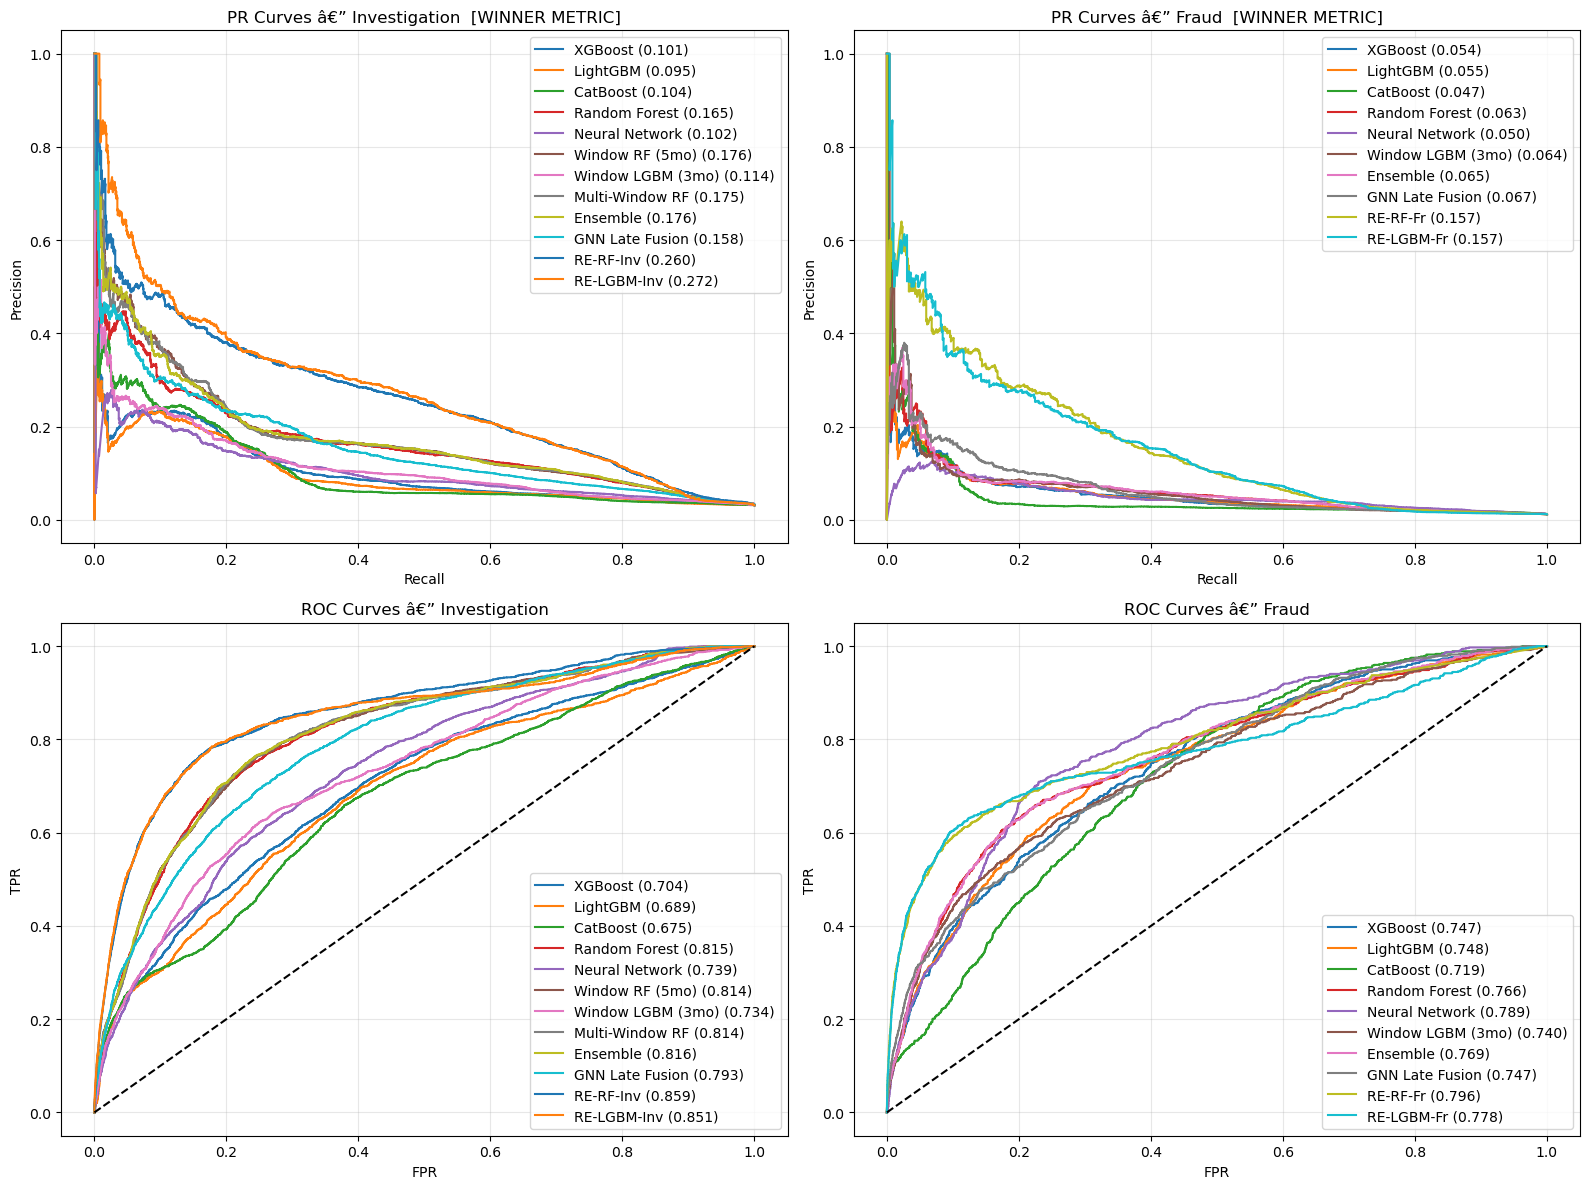

  Curves plotted


In [42]:
# PR Curves (winner metric) + ROC Curves
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# PR â€” Investigation
ax = axes[0, 0]
for r in results_inv:
    p, rec, _ = precision_recall_curve(y_test_inv, r["y_pred_proba"])
    ax.plot(rec, p, label=f"{r['model_name']} ({r['pr_auc']:.3f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("PR Curves â€” Investigation  [WINNER METRIC]")
ax.legend(loc="best"); ax.grid(alpha=0.3)

# PR â€” Fraud
ax = axes[0, 1]
for r in results_fraud:
    p, rec, _ = precision_recall_curve(y_test_fraud, r["y_pred_proba"])
    ax.plot(rec, p, label=f"{r['model_name']} ({r['pr_auc']:.3f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("PR Curves â€” Fraud  [WINNER METRIC]")
ax.legend(loc="best"); ax.grid(alpha=0.3)

# ROC â€” Investigation
ax = axes[1, 0]
for r in results_inv:
    fpr, tpr, _ = roc_curve(y_test_inv, r["y_pred_proba"])
    ax.plot(fpr, tpr, label=f"{r['model_name']} ({r['roc_auc']:.3f})")
ax.plot([0,1],[0,1],"k--")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("ROC Curves â€” Investigation")
ax.legend(loc="lower right"); ax.grid(alpha=0.3)

# ROC â€” Fraud
ax = axes[1, 1]
for r in results_fraud:
    fpr, tpr, _ = roc_curve(y_test_fraud, r["y_pred_proba"])
    ax.plot(fpr, tpr, label=f"{r['model_name']} ({r['roc_auc']:.3f})")
ax.plot([0,1],[0,1],"k--")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("ROC Curves â€” Fraud")
ax.legend(loc="lower right"); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("  Curves plotted")

In [43]:
# Recompute winners from full results lists (includes rolling entity models)
best_inv   = max(results_inv,   key=lambda x: x["pr_auc"])
best_fraud = max(results_fraud, key=lambda x: x["pr_auc"])

# Final Summary
print("="*65)
print("FINAL SUMMARY")
print("="*65)

for label, best, y_true in [
    ("TARGET_AS_INVESTIGATION", best_inv,   y_test_inv),
    ("TARGET_AS_FRAUD",         best_fraud, y_test_fraud),
]:
    print(f"\n{label}")
    print(f"  Winner Model : {best['model_name']}")
    print(f"  PR-AUC       : {best['pr_auc']:.4f}  <-- deciding metric")
    print(f"  ROC-AUC      : {best['roc_auc']:.4f}")
    print(f"  Default (0.5): P={best['precision']:.4f} R={best['recall']:.4f} F1={best['f1']:.4f}")
    print(f"  Optimized ({best['opt_thresh']:.3f}): "
          f"P={best['opt_precision']:.4f} R={best['opt_recall']:.4f} F1={best['opt_f1']:.4f}")
    yp = (best["y_pred_proba"] >= best["opt_thresh"]).astype(int)
    print("\n  Classification Report (optimized threshold):")
    print(classification_report(y_true, yp, target_names=["Class 0", "Class 1 (Fraud)"]))

FINAL SUMMARY

TARGET_AS_INVESTIGATION
  Winner Model : RE-LGBM-Inv
  PR-AUC       : 0.2724  <-- deciding metric
  ROC-AUC      : 0.8508
  Default (0.5): P=0.2434 R=0.5203 F1=0.3316
  Optimized (0.395): P=0.2088 R=0.6000 F1=0.3098

  Classification Report (optimized threshold):
                 precision    recall  f1-score   support

        Class 0       0.99      0.93      0.95     56998
Class 1 (Fraud)       0.21      0.60      0.31      1870

       accuracy                           0.92     58868
      macro avg       0.60      0.76      0.63     58868
   weighted avg       0.96      0.92      0.93     58868


TARGET_AS_FRAUD
  Winner Model : RE-LGBM-Fr
  PR-AUC       : 0.1574  <-- deciding metric
  ROC-AUC      : 0.7776
  Default (0.5): P=0.2066 R=0.3033 F1=0.2458
  Optimized (0.064): P=0.0722 R=0.6011 F1=0.1289

  Classification Report (optimized threshold):
                 precision    recall  f1-score   support

        Class 0       0.99      0.90      0.95     58146
Class